In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pynwb import NWBHDF5IO
from scipy.signal import find_peaks

path = "data/AO026_20181122_180943.nwb"
THIS_AREA = "wS1"

with NWBHDF5IO(path, "r") as io:
    nwb = io.read()
    tr = nwb.trials.to_dataframe().copy()
    areas = nwb.units["Target_area"].data[:]
    areas = np.array([a.decode() if isinstance(a, (bytes, bytearray)) else a for a in areas])
    unit_mask = (areas == THIS_AREA)

    spike_times = []
    for i in np.where(unit_mask)[0]:
        st = nwb.units["spike_times"][i]
        spike_times.append(np.asarray(st))

print("Number of selected units:", len(spike_times))
print("Example spike train length:", len(spike_times[0]))
print("First 10 spikes:", spike_times[0][:10])
print("Total trials:", len(tr))
print("Stim trials:", tr["whisker_stim"].sum())
print("Catch trials:", tr["no_stim"].sum())

Bin_size = 0.01 # 10 ms bins
AP_Bin_Resolution = 1.0 / Bin_size

duration = float(tr["stop_time"].max())
n_bins = int(np.round(duration * AP_Bin_Resolution))
edges = np.linspace(0.0, n_bins * Bin_size, n_bins + 1)

AP_Bin_Matrx = np.zeros((len(spike_times), n_bins), dtype=np.float32)

for n, st in enumerate(spike_times):
    counts, _ = np.histogram(st, bins=edges)
    AP_Bin_Matrx[n, :] = counts

Mean_Pop_Act = AP_Bin_Matrx.mean(axis=0)

print("Total spikes in AP:", AP_Bin_Matrx.sum())

# CREATION MATRICES DES ACTIVITE POUR CHAQUE AMP ET CATCH (BRUIT)

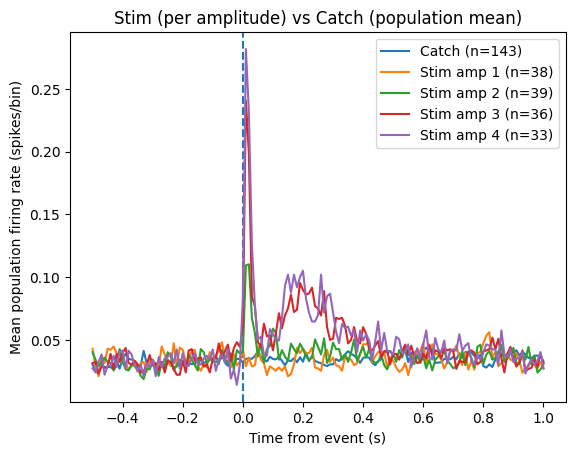

In [2]:
amps_stim = [1,2,3,4]

def event_triggered_matrix(AP_Bin_Matrx, event_times, AP_Bin_Resolution, pre_bins=50, post_bins=100):
    W = pre_bins + post_bins + 1
    mats = []
    for ev in event_times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        pt1, pt2 = pt - pre_bins, pt + post_bins
        if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
            continue
        mats.append(AP_Bin_Matrx[:, pt1:pt2+1].astype(np.float32))  # (n_neurons, W)
    if len(mats) == 0:
        return None, 0
    return np.stack(mats, axis=0), len(mats)  # (n_trials, n_neurons, W)

# event-triggered mean
def event_triggered_mean(AP_Bin_Matrx, event_times, AP_Bin_Resolution, pre_bins=50, post_bins=100):
    W = pre_bins + post_bins + 1
    M = np.zeros((AP_Bin_Matrx.shape[0], W), dtype=np.float32)
    n = 0
    for ev in event_times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        pt1, pt2 = pt - pre_bins, pt + post_bins
        if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
            continue
        M += AP_Bin_Matrx[:, pt1:pt2+1]
        n += 1
    return M / max(n, 1), n

# stim times par amplitude
stim_sel = tr["whisker_stim_time"].notna() & tr["whisker_stim_amplitude"].isin(amps_stim)

Stim_times_by_amp = {
    a: np.sort(tr.loc[stim_sel & (tr["whisker_stim_amplitude"] == a), "whisker_stim_time"].to_numpy())
    for a in amps_stim
}

catch_sel = tr["no_stim"].astype(bool) & tr["no_stim_time"].notna()
Catch_times = np.sort((tr.loc[catch_sel, "no_stim_time"]).to_numpy())

pre_bins, post_bins = 50, 100
time_axis = (np.arange(pre_bins + post_bins + 1) - pre_bins) * Bin_size

CATCH_MTRX, n_catch = event_triggered_mean(AP_Bin_Matrx, Catch_times, AP_Bin_Resolution, pre_bins, post_bins)

plt.figure()
plt.plot(time_axis, CATCH_MTRX.mean(axis=0), label=f"Catch (n={n_catch})")
plt.axvline(0, linestyle="--")

STM_by_amp = {}
for a in amps_stim:
    STM_by_amp[a], n_st = event_triggered_mean(AP_Bin_Matrx, Stim_times_by_amp[a], AP_Bin_Resolution, pre_bins, post_bins)
    plt.plot(time_axis, STM_by_amp[a].mean(axis=0), label=f"Stim amp {a} (n={n_st})")


plt.xlabel("Time from event (s)")
plt.ylabel("Mean population firing rate (spikes/bin)")
plt.title("Stim (per amplitude) vs Catch (population mean)")
plt.legend()
plt.show()

# EXPLORATION ACTIVITE CONTINUE

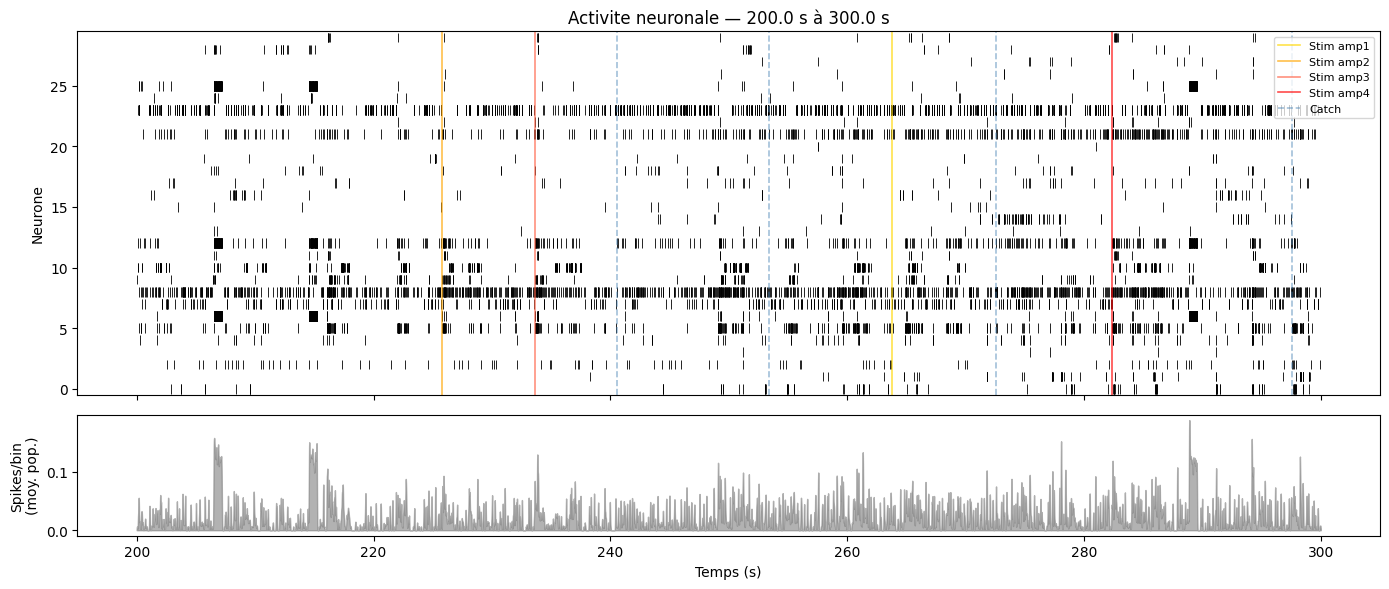

In [3]:
# Activite neuronale sur 10 secondes
t0 = 200
t1 = t0 + 100

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

# --- Raster plot ---
ax = axes[0]
for n, st in enumerate(spike_times):
    spk = st[(st >= t0) & (st <= t1)]
    ax.vlines(spk, n - 0.4, n + 0.4, linewidth=0.6, color="black")

# Marquer les stim et catch dans la fenetre
colors_amp = {1: "gold", 2: "orange", 3: "tomato", 4: "red"}
for a in amps_stim:
    for st in Stim_times_by_amp[a]:
        if t0 <= st <= t1:
            ax.axvline(st, color=colors_amp[a], alpha=0.7, linewidth=1.2, label=f"Stim amp{a}")
for ct in Catch_times:
    if t0 <= ct <= t1:
        ax.axvline(ct, color="steelblue", alpha=0.5, linewidth=1.2, linestyle="--", label="Catch")


# Deduplication de la legende
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=8, loc="upper right")
ax.set_ylabel("Neurone")
ax.set_title(f"Activite neuronale — {t0:.1f} s à {t1:.1f} s")
ax.set_ylim(-0.5, len(spike_times) - 0.5)

# --- Firing rate moyen (lissage gaussien) ---
ax2 = axes[1]
b0, b1 = int(t0 * AP_Bin_Resolution), int(t1 * AP_Bin_Resolution)
t_slice = np.arange(b0, b1) * Bin_size
rate_slice = AP_Bin_Matrx[:, b0:b1].mean(axis=0)  # spikes/bin

from scipy.ndimage import gaussian_filter1d
rate_smooth = gaussian_filter1d(rate_slice, sigma=2)  # sigma=2 bins = 20ms

ax2.fill_between(t_slice, rate_smooth, alpha=0.6, color="gray")
ax2.set_xlabel("Temps (s)")
ax2.set_ylabel("Spikes/bin\n(moy. pop.)")

plt.tight_layout()
plt.show()


Top neurones amp4 par d-prime (0-50ms vs catch):
  #1  neurone  6  d'=3.018  mu_amp4=0.7939  mu_catch=0.0322
  #2  neurone 22  d'=2.398  mu_amp4=0.6909  mu_catch=0.0154
  #3  neurone  5  d'=2.055  mu_amp4=0.5455  mu_catch=0.0839
  #4  neurone 12  d'=1.657  mu_amp4=0.3273  mu_catch=0.0713
  #5  neurone 21  d'=1.574  mu_amp4=0.4182  mu_catch=0.0601
  #6  neurone  8  d'=1.136  mu_amp4=0.3333  mu_catch=0.1441
  #7  neurone 18  d'=0.964  mu_amp4=0.1576  mu_catch=0.0140
  #8  neurone  4  d'=0.923  mu_amp4=0.1030  mu_catch=0.0042
  #9  neurone 27  d'=0.894  mu_amp4=0.0727  mu_catch=0.0028
  #10  neurone  1  d'=0.885  mu_amp4=0.2000  mu_catch=0.0573


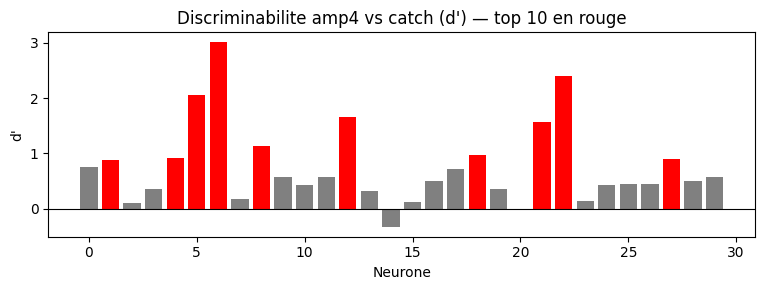

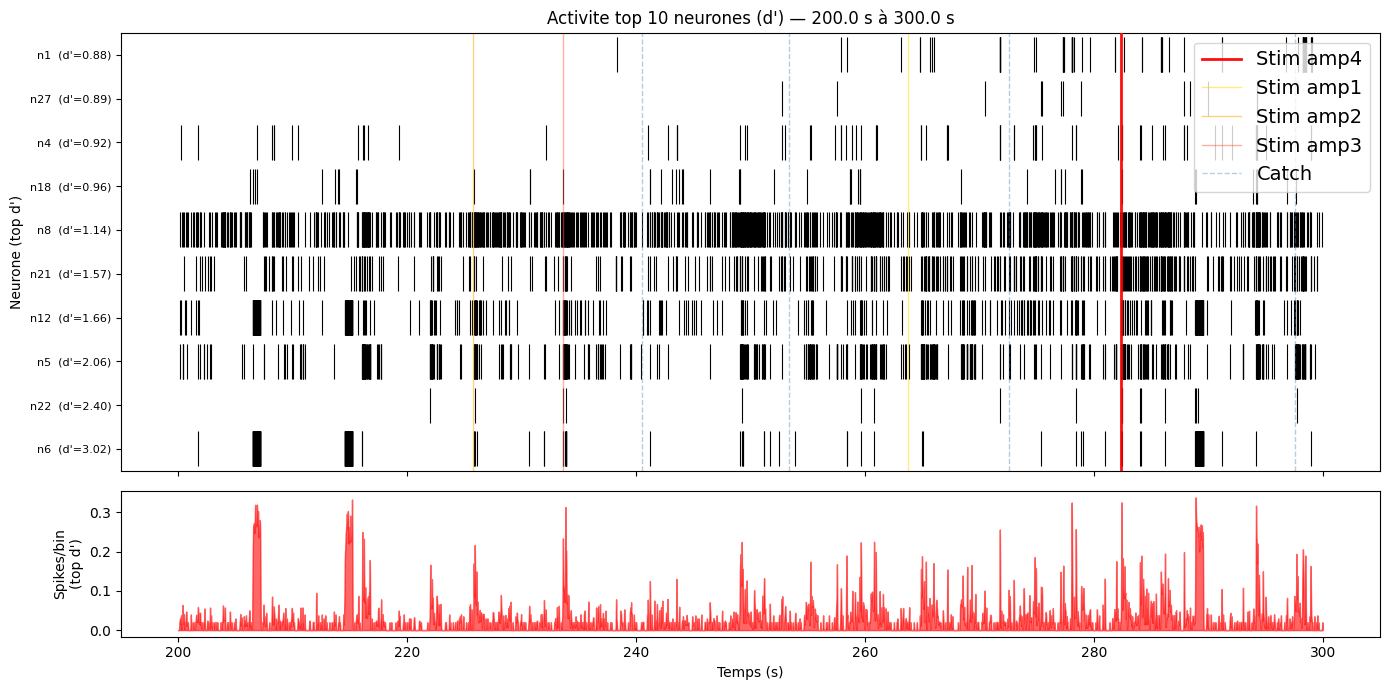

In [4]:
# d' (d-prime) : mesure de separabilite entre deux distributions (SDT)
# d' = (mean_stim - mean_catch) / pooled_std
# Combine amplitude de la reponse ET sa consistance trial-par-trial.
# d'=0 → neurone non discriminant | d'>2 → neurone tres selectif

# Extraction trial-par-trial : reponse moyenne 0-50ms (bins 50:55) par neurone
mats_amp4, _ = event_triggered_matrix(AP_Bin_Matrx, Stim_times_by_amp[4],
                                       AP_Bin_Resolution, pre_bins, post_bins)
mats_catch, _ = event_triggered_matrix(AP_Bin_Matrx, Catch_times,
                                        AP_Bin_Resolution, pre_bins, post_bins)

# mats shape: (n_trials, n_neurons, W)
# Fenetre 0-50ms = bins 50:55
resp_amp4  = mats_amp4[:, :, 50:55].mean(axis=2)   # (n_trials_amp4, n_neurons)
resp_catch = mats_catch[:, :, 50:55].mean(axis=2)  # (n_trials_catch, n_neurons)

mu4  = resp_amp4.mean(axis=0)
mu_c = resp_catch.mean(axis=0)
std4  = resp_amp4.std(axis=0)
std_c = resp_catch.std(axis=0)

pooled_std = np.sqrt((std4**2 + std_c**2) / 2 + 1e-12)
dprime = (mu4 - mu_c) / pooled_std

# Top neurones par d'
top_n = 10
sorted_idx = np.argsort(dprime)[::-1]
top_neurons = sorted_idx[:top_n]

print("Top neurones amp4 par d-prime (0-50ms vs catch):")
for rank, n in enumerate(top_neurons):
    print(f"  #{rank+1}  neurone {n:2d}  d'={dprime[n]:.3f}  mu_amp4={mu4[n]:.4f}  mu_catch={mu_c[n]:.4f}")

# Barplot d-prime
fig, ax = plt.subplots(figsize=(8, 3))
colors_bar = ["red" if i in top_neurons else "gray" for i in range(len(dprime))]
ax.bar(np.arange(len(dprime)), dprime, color=colors_bar)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Neurone")
ax.set_ylabel("d'")
ax.set_title(f"Discriminabilite amp4 vs catch (d') — top {top_n} en rouge")
plt.tight_layout()
plt.show()

# Raster + firing rate moyen uniquement sur les top neurones
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

ax = axes[0]
for rank, n in enumerate(top_neurons):
    spk = spike_times[n][(spike_times[n] >= t0) & (spike_times[n] <= t1)]
    ax.vlines(spk, rank - 0.4, rank + 0.4, linewidth=0.8, color="black")

# Stim amp4 : ligne rouge epaisse sur les deux panels
for st in Stim_times_by_amp[4]:
    if t0 <= st <= t1:
        ax.axvline(st, color="red", alpha=0.95, linewidth=2.0, zorder=5, label="Stim amp4")
        # axes[1].axvline(st, color="red", alpha=0.95, linewidth=2.0, zorder=5)

# Autres stim et catch
for a in [1, 2, 3]:
    for st in Stim_times_by_amp[a]:
        if t0 <= st <= t1:
            ax.axvline(st, color=colors_amp[a], alpha=0.5, linewidth=1.0, label=f"Stim amp{a}")
for ct in Catch_times:
    if t0 <= ct <= t1:
        ax.axvline(ct, color="steelblue", alpha=0.4, linewidth=1.0, linestyle="--", label="Catch")

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=14, loc="upper right")
ax.set_yticks(range(top_n))
ax.set_yticklabels([f"n{n}  (d'={dprime[n]:.2f})" for n in top_neurons], fontsize=8)
ax.set_ylabel("Neurone (top d')")
ax.set_title(f"Activite top {top_n} neurones (d') — {t0:.1f} s à {t1:.1f} s")
ax.set_ylim(-0.5, top_n - 0.5)

# Firing rate moyen sur les top neurones uniquement
AP_top = AP_Bin_Matrx[top_neurons, :]
rate_top = AP_top[:, b0:b1].mean(axis=0)
rate_top_smooth = gaussian_filter1d(rate_top, sigma=2)

axes[1].fill_between(t_slice, rate_top_smooth, alpha=0.6, color="red")
axes[1].set_xlabel("Temps (s)")
axes[1].set_ylabel("Spikes/bin\n(top d')")

plt.tight_layout()
plt.show()


# TECHNIQUE CODING DIRECTION

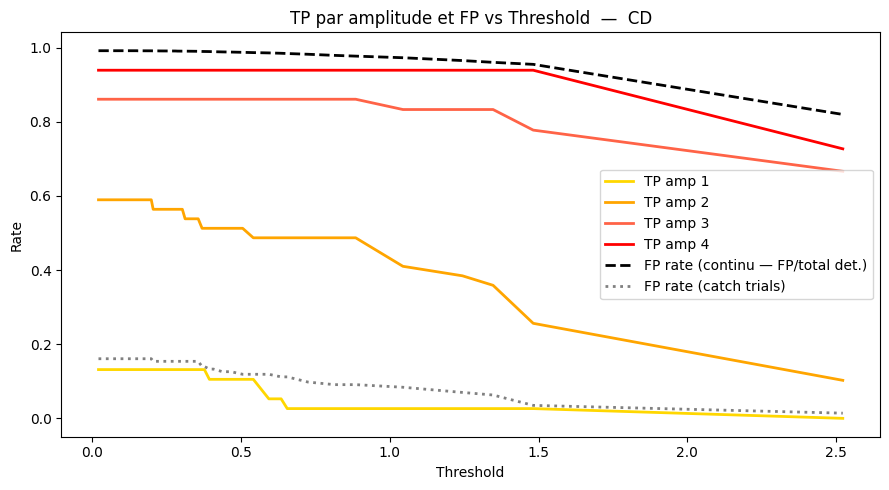

Number of false detection at the best threshold (0.02): 11264 (FP rate: 0.99)


In [ ]:
# Creation CD1 : pic principal 0-50ms (amp4)

Pop_Vect_Stim  = STM_by_amp[4][:, 50:55].mean(axis=1)
Pop_Vect_Catch = CATCH_MTRX[:, 50:55].mean(axis=1)

CD = Pop_Vect_Stim - Pop_Vect_Catch
CD = CD / (np.linalg.norm(CD) + 1e-12)

print("CD1 norm:", np.linalg.norm(CD), "shape:", CD.shape)

# Detection sur signal continu via projection CD1

# projection
score = CD @ AP_Bin_Matrx
t_sig = np.arange(len(score)) * Bin_size

# Peak detection
tol_post     = 0.05   # fenetre 50ms apres stim pour compter un TP
refractory_s = 0.2    # periode refractaire entre deux detections

t_start = float(tr["start_time"].min())
t_end   = float(tr["stop_time"].max())

def detect_peaks(score, t, thr, refractory_s, Bin_size, t_start, t_end):
    mask = (t >= t_start) & (t <= t_end) & (score > thr)
    idx  = np.where(mask)[0]
    if idx.size == 0:
        return np.array([], dtype=float)
    cuts   = np.where(np.diff(idx) > 1)[0] + 1
    groups = np.split(idx, cuts)
    peaks  = np.array([g[np.argmax(score[g])] for g in groups], dtype=int)
    min_b  = int(np.round(refractory_s / Bin_size))
    keep   = [peaks[0]]
    for p in peaks[1:]:
        if p - keep[-1] >= min_b:
            keep.append(p)
        elif score[p] > score[keep[-1]]:
            keep[-1] = p
    return t[np.array(keep, dtype=int)]

# threshold
in_range = (t_sig >= t_start) & (t_sig <= t_end)
ths      = np.percentile(score[in_range], np.linspace(50, 99.9, 80))

all_stim_times = np.sort(np.concatenate([Stim_times_by_amp[a] for a in amps_stim]))
n_catch_trials = len(Catch_times)

tp_curves        = {a: [] for a in amps_stim}
fp_cont_curve    = []   # FP / total detections (signal continu)
fp_catch_curve   = []   # detections dans fenetres catch / n_catch_trials

for thr in ths:
    det_t = detect_peaks(score, t_sig, thr, refractory_s, Bin_size, t_start, t_end)
    n_det = max(len(det_t), 1)

    # FP continu : detections hors de toute fenetre stim / total detections
    in_win_any = np.zeros(len(det_t), dtype=bool)
    for st in all_stim_times:
        in_win_any |= (det_t >= st) & (det_t <= st + tol_post)
    fp_cont_curve.append(np.sum(~in_win_any) / n_det)

    # keep number of false detections at best threshold for later
    if len(fp_cont_curve) == 1:  # first threshold (lowest)
        in_win_any_at_best = in_win_any.copy()
        n_det_at_best = n_det

    # FP catch : combien de catch trials ont une detection dans leur fenetre
    hits_catch = sum(
        np.any((det_t >= st) & (det_t <= st + tol_post))
        for st in Catch_times
    )
    fp_catch_curve.append(hits_catch / max(n_catch_trials, 1))

    # TP par amplitude
    for a in amps_stim:
        hits = sum(
            np.any((det_t >= st) & (det_t <= st + tol_post))
            for st in Stim_times_by_amp[a]
        )
        tp_curves[a].append(hits / max(len(Stim_times_by_amp[a]), 1))

tp_curves      = {a: np.array(tp_curves[a]) for a in amps_stim}
fp_cont_curve  = np.array(fp_cont_curve)
fp_catch_curve = np.array(fp_catch_curve)

# plot
colors_amp = {1: "gold", 2: "orange", 3: "tomato", 4: "red"}

plt.figure(figsize=(9, 5))
for a in amps_stim:
    plt.plot(ths, tp_curves[a], color=colors_amp[a], lw=2, label=f"TP amp {a}")
plt.plot(ths, fp_cont_curve,  color="black",  lw=2, linestyle="--", label="FP rate (continu — FP/total det.)")
plt.plot(ths, fp_catch_curve, color="gray",   lw=2, linestyle=":",  label="FP rate (catch trials)")
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("TP par amplitude et FP vs Threshold  —  CD")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Number of false detection at the best threshold ({ths[0]:.2f}): {n_det_at_best} (FP rate: {np.sum(~in_win_any_at_best) / n_det_at_best:.2f})")

Threshold : 0.158  |  FP : 10935
  TP amp1 : 5
  TP amp2 : 23
  TP amp3 : 31
  TP amp4 : 31
Cosine sim amp1 : 0.431 ± 0.131
Cosine sim amp2 : 0.614 ± 0.163
Cosine sim amp3 : 0.792 ± 0.101
Cosine sim amp4 : 0.830 ± 0.056
Cosine sim FP   : 0.432 ± 0.147


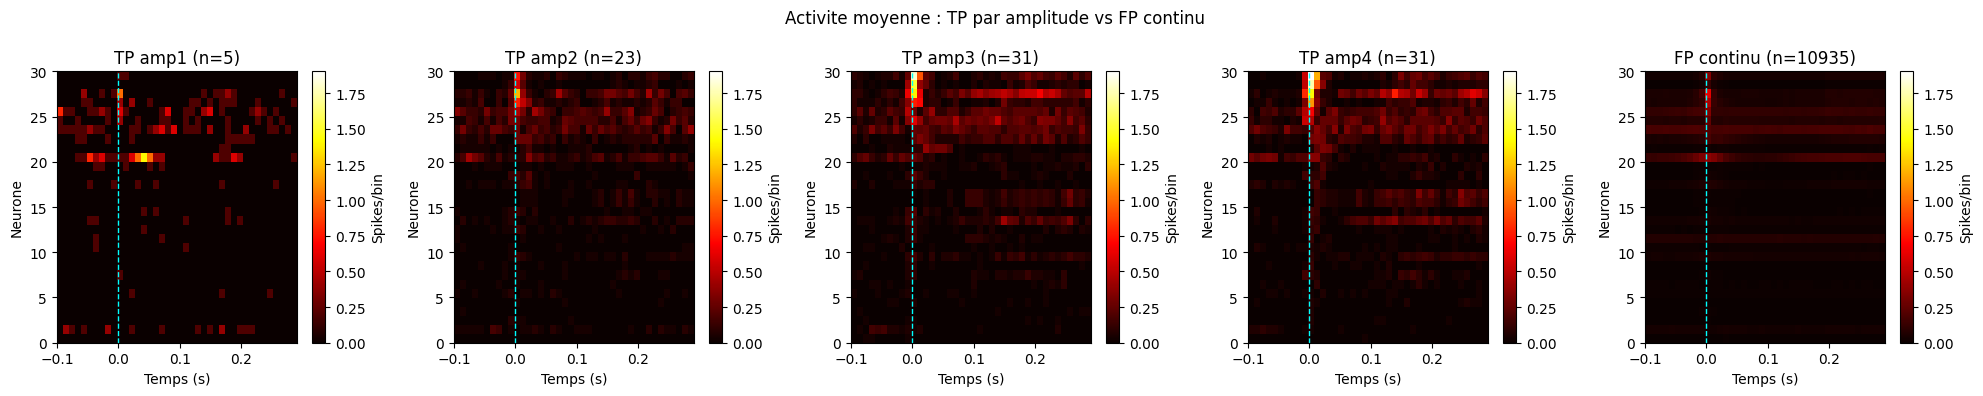

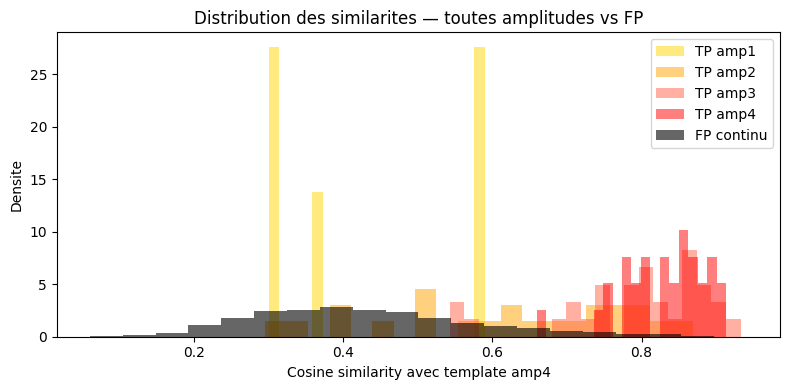

In [7]:
# Similarite entre FP continu et vraies reponses (toutes amplitudes)
# On montre que les FP ne sont pas du bruit mais des evenements spontanes qui ressemblent a une stim

# Template = reponse stim amp4 normalisee
template = Pop_Vect_Stim / (np.linalg.norm(Pop_Vect_Stim) + 1e-12)

# Seuil median pour avoir assez de FP
thr_fixed = np.median(ths)
det_t = detect_peaks(score, t_sig, thr_fixed, refractory_s, Bin_size, t_start, t_end)

# FP : hors de toute fenetre stim
in_win_any = np.zeros(len(det_t), dtype=bool)
for st in all_stim_times:
    in_win_any |= (det_t >= st) & (det_t <= st + tol_post)
fp_times = det_t[~in_win_any]

# TP par amplitude
tp_times_by_amp = {}
for a in amps_stim:
    in_win = np.zeros(len(det_t), dtype=bool)
    for st in Stim_times_by_amp[a]:
        in_win |= (det_t >= st) & (det_t <= st + tol_post)
    tp_times_by_amp[a] = det_t[in_win]

print(f"Threshold : {thr_fixed:.3f}  |  FP : {len(fp_times)}")
for a in amps_stim:
    print(f"  TP amp{a} : {len(tp_times_by_amp[a])}")

# Extraction des fenetres
pre, post = 10, 30
t_win = (np.arange(pre + post) - pre) * Bin_size

def extract_windows(times, AP_Bin_Matrx, AP_Bin_Resolution, pre, post):
    segs = []
    for ev in times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        if pt - pre < 0 or pt + post > AP_Bin_Matrx.shape[1]:
            continue
        segs.append(AP_Bin_Matrx[:, pt - pre:pt + post])
    return np.array(segs) if segs else None

def pop_vecs_at_peak(segs, pre, W=5):
    vecs = segs[:, :, pre:pre+W].mean(axis=2)
    return vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-12)

segs_fp = extract_windows(fp_times, AP_Bin_Matrx, AP_Bin_Resolution, pre, post)
fp_vecs = pop_vecs_at_peak(segs_fp, pre)
cos_fp  = fp_vecs @ template

segs_by_amp = {}
cos_by_amp  = {}
for a in amps_stim:
    segs_by_amp[a] = extract_windows(tp_times_by_amp[a], AP_Bin_Matrx, AP_Bin_Resolution, pre, post)
    if segs_by_amp[a] is not None:
        vecs = pop_vecs_at_peak(segs_by_amp[a], pre)
        cos_by_amp[a] = vecs @ template
        print(f"Cosine sim amp{a} : {cos_by_amp[a].mean():.3f} ± {cos_by_amp[a].std():.3f}")
print(f"Cosine sim FP   : {cos_fp.mean():.3f} ± {cos_fp.std():.3f}")

# Heatmaps : une par amplitude + FP
n_cols = len(amps_stim) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

# Trier les neurones par reponse amp4
mean_tp4 = segs_by_amp[4].mean(axis=0)
sort_idx = np.argsort(mean_tp4[:, pre:pre+5].mean(axis=1))[::-1]
mean_fp  = segs_fp.mean(axis=0)
lim = max(segs_by_amp[a].mean(axis=0).max() for a in amps_stim if segs_by_amp[a] is not None)
lim = max(lim, mean_fp.max())

for i, a in enumerate(amps_stim):
    if segs_by_amp[a] is None:
        continue
    data = segs_by_amp[a].mean(axis=0)[sort_idx]
    im = axes[i].imshow(data, aspect="auto", cmap="hot", vmin=0, vmax=lim,
                        extent=[t_win[0], t_win[-1], 0, data.shape[0]])
    axes[i].axvline(0, color="cyan", lw=1, linestyle="--")
    axes[i].set_title(f"TP amp{a} (n={len(tp_times_by_amp[a])})")
    axes[i].set_xlabel("Temps (s)")
    axes[i].set_ylabel("Neurone")
    plt.colorbar(im, ax=axes[i], label="Spikes/bin")

data_fp = mean_fp[sort_idx]
im = axes[-1].imshow(data_fp, aspect="auto", cmap="hot", vmin=0, vmax=lim,
                     extent=[t_win[0], t_win[-1], 0, data_fp.shape[0]])
axes[-1].axvline(0, color="cyan", lw=1, linestyle="--")
axes[-1].set_title(f"FP continu (n={len(fp_times)})")
axes[-1].set_xlabel("Temps (s)")
axes[-1].set_ylabel("Neurone")
plt.colorbar(im, ax=axes[-1], label="Spikes/bin")

plt.suptitle("Activite moyenne : TP par amplitude vs FP continu")
plt.tight_layout()
plt.show()

# Distribution cosine similarities
plt.figure(figsize=(8, 4))
for a in amps_stim:
    if a in cos_by_amp:
        plt.hist(cos_by_amp[a], bins=20, alpha=0.5, color=colors_amp[a], label=f"TP amp{a}", density=True)
plt.hist(cos_fp, bins=20, alpha=0.6, color="black", label=f"FP continu", density=True)
plt.xlabel("Cosine similarity avec template amp4")
plt.ylabel("Densite")
plt.title("Distribution des similarites — toutes amplitudes vs FP")
plt.legend()
plt.tight_layout()
plt.show()


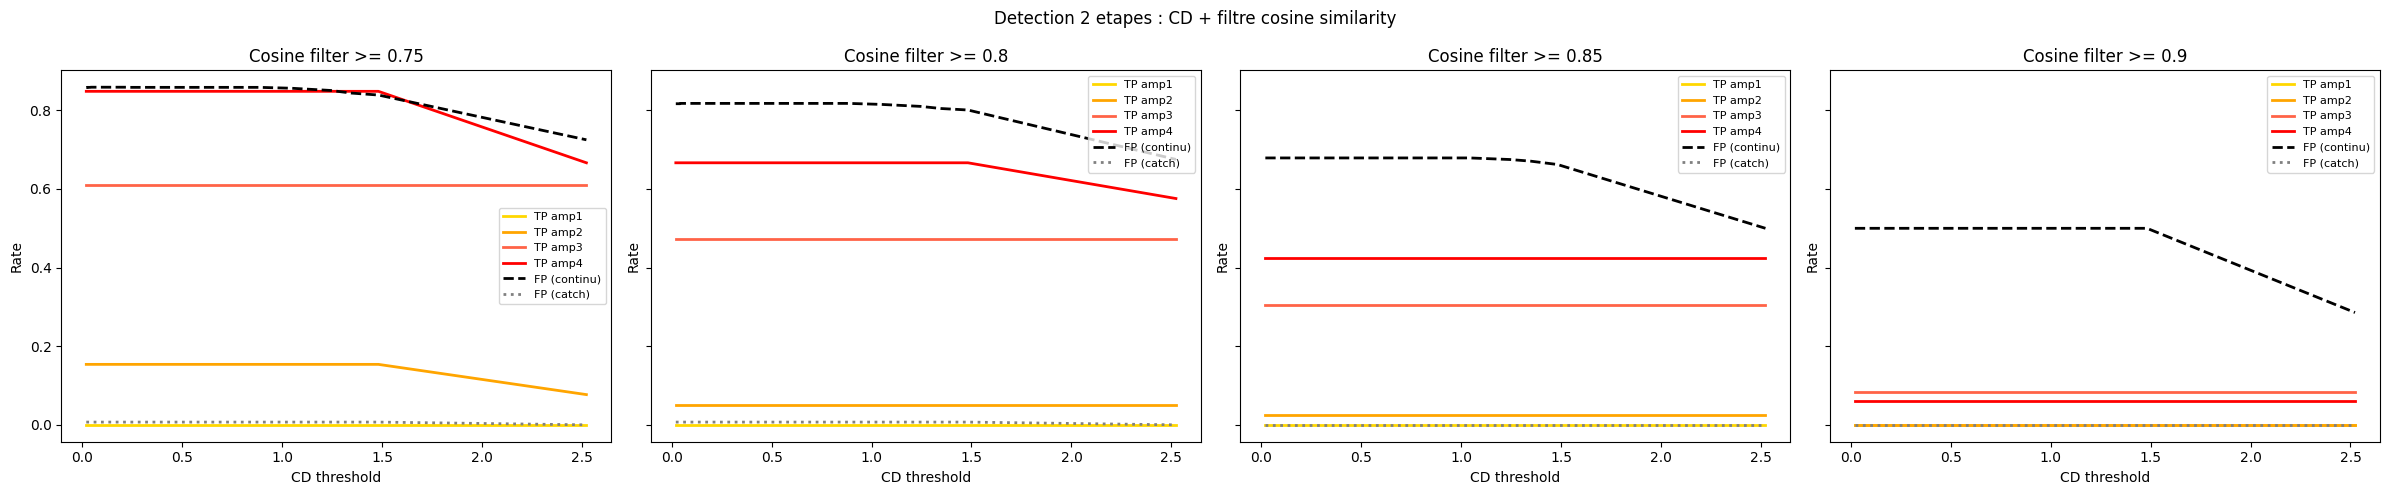

In [8]:
# second detection with cosine similarity
# Etape 1 : detecter les pics sur le score CD
# Etape 2 : pour chaque detection, calculer la cosine similarity de la fenetre de population avec le template
# Garder uniquement les detections au-dessus d'un seuil cosine

W_cos = 5  # fenetre 50ms pour calculer le vecteur population

def cosine_sim_at_times(times, AP_Bin_Matrx, AP_Bin_Resolution, template, W):
    sims = []
    for ev in times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        if pt + W > AP_Bin_Matrx.shape[1]:
            sims.append(0.0)
            continue
        vec = AP_Bin_Matrx[:, pt:pt + W].mean(axis=1).astype(np.float32)
        vec = vec / (np.linalg.norm(vec) + 1e-12)
        sims.append(float(vec @ template))
    return np.array(sims)

# Sweep CD threshold avec filtre cosine fixe
cos_thresholds = [0.75, 0.8, 0.85, 0.9]
colors_cos = {0.75: "magenta", 0.8: "yellow", 0.85: "brown", 0.9: "pink"}

fig, axes = plt.subplots(1, len(cos_thresholds), figsize=(6 * len(cos_thresholds), 5), sharey=True)

for ax, cos_thr in zip(axes, cos_thresholds):
    tp_c  = {a: [] for a in amps_stim}
    fp_co = []
    fp_ca = []

    for thr in ths:
        det_t = detect_peaks(score, t_sig, thr, refractory_s, Bin_size, t_start, t_end)

        # Filtre cosine
        if len(det_t) > 0:
            sims  = cosine_sim_at_times(det_t, AP_Bin_Matrx, AP_Bin_Resolution, template, W_cos)
            det_t = det_t[sims >= cos_thr]

        n_det = max(len(det_t), 1)

        in_win_any = np.zeros(len(det_t), dtype=bool)
        for st in all_stim_times:
            in_win_any |= (det_t >= st) & (det_t <= st + tol_post)
        fp_co.append(np.sum(~in_win_any) / n_det)

        hits_catch = sum(
            np.any((det_t >= st) & (det_t <= st + tol_post))
            for st in Catch_times
        )
        fp_ca.append(hits_catch / max(n_catch_trials, 1))

        for a in amps_stim:
            hits = sum(
                np.any((det_t >= st) & (det_t <= st + tol_post))
                for st in Stim_times_by_amp[a]
            )
            tp_c[a].append(hits / max(len(Stim_times_by_amp[a]), 1))

    for a in amps_stim:
        ax.plot(ths, tp_c[a], color=colors_amp[a], lw=2, label=f"TP amp{a}")
    ax.plot(ths, fp_co, color="black", lw=2, linestyle="--", label="FP (continu)")
    ax.plot(ths, fp_ca, color="gray",  lw=2, linestyle=":",  label="FP (catch)")
    ax.set_xlabel("CD threshold")
    ax.set_ylabel("Rate")
    ax.set_title(f"Cosine filter >= {cos_thr}")
    ax.legend(fontsize=8)

plt.suptitle("Detection 2 etapes : CD + filtre cosine similarity")
plt.tight_layout()
plt.show()



Dist <= 0.71 (≈ cosine 0.75)  |  Best CD threshold = 1.482
  Total detections : 355  |  FP absolus : 298  |  FP rate : 0.84
  TP amp1 :   0 / 38  (rate=0.00)
  TP amp2 :   6 / 39  (rate=0.15)
  TP amp3 :  22 / 36  (rate=0.61)
  TP amp4 :  29 / 33  (rate=0.88)

Dist <= 0.63 (≈ cosine 0.8)  |  Best CD threshold = 2.523
  Total detections : 112  |  FP absolus : 75  |  FP rate : 0.67
  TP amp1 :   0 / 38  (rate=0.00)
  TP amp2 :   2 / 39  (rate=0.05)
  TP amp3 :  16 / 36  (rate=0.44)
  TP amp4 :  19 / 33  (rate=0.58)

Dist <= 0.55 (≈ cosine 0.85)  |  Best CD threshold = 2.523
  Total detections : 52  |  FP absolus : 26  |  FP rate : 0.50
  TP amp1 :   0 / 38  (rate=0.00)
  TP amp2 :   1 / 39  (rate=0.03)
  TP amp3 :  11 / 36  (rate=0.31)
  TP amp4 :  14 / 33  (rate=0.42)

Dist <= 0.45 (≈ cosine 0.9)  |  Best CD threshold = 0.021
  Total detections : 11  |  FP absolus : 5  |  FP rate : 0.45
  TP amp1 :   0 / 38  (rate=0.00)
  TP amp2 :   0 / 39  (rate=0.00)
  TP amp3 :   3 / 36  (rate=0.08

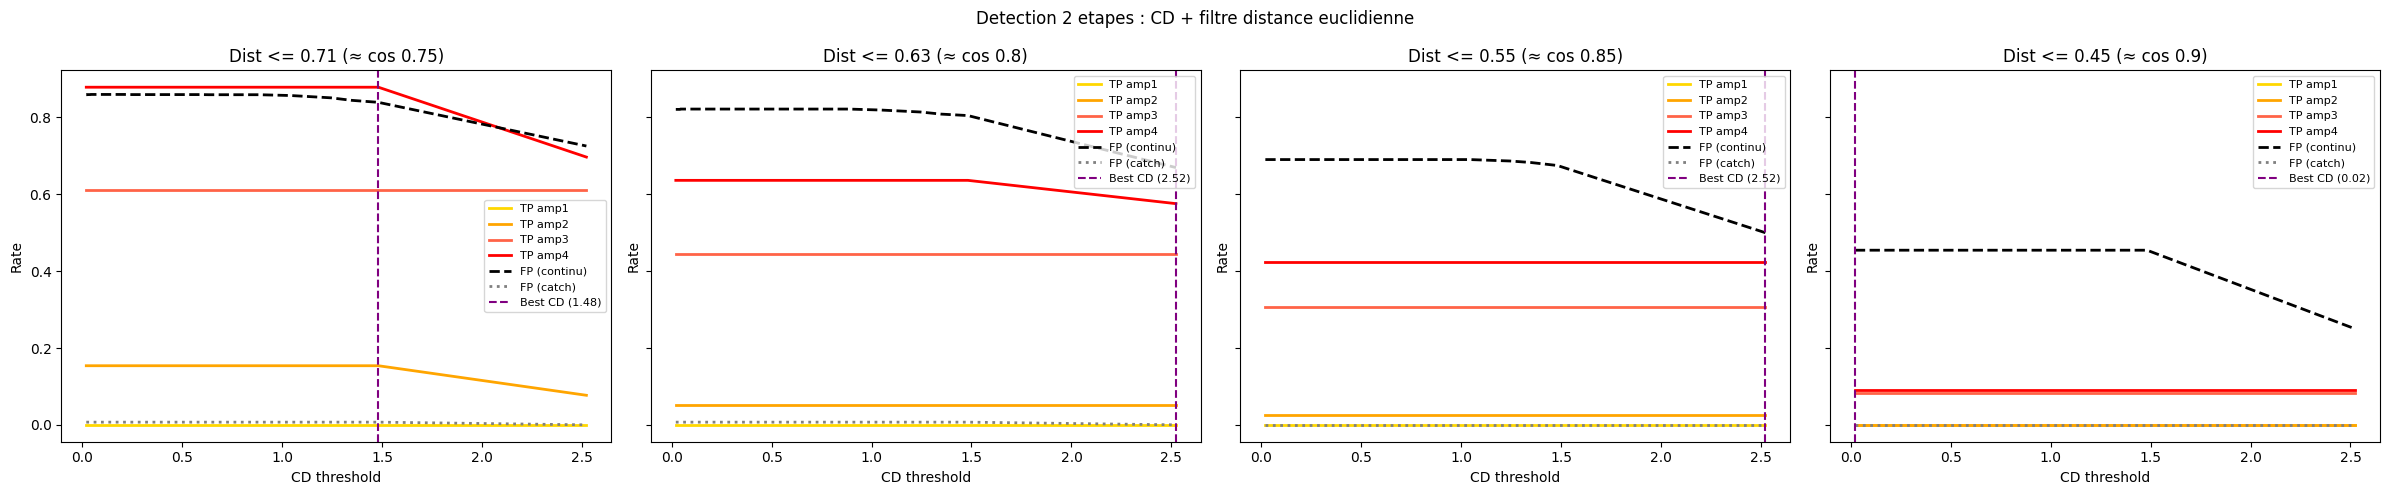

In [9]:
# Detection 2 etapes : CD + filtre distance euclidienne
# Meme pipeline que cosine mais avec distance euclidienne (dist <= seuil)

W_euc = 5  # fenetre 50ms

def euclidean_dist_at_times(times, AP_Bin_Matrx, AP_Bin_Resolution, template, W):
    dists = []
    for ev in times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        if pt + W > AP_Bin_Matrx.shape[1]:
            dists.append(np.inf)
            continue
        vec = AP_Bin_Matrx[:, pt:pt + W].mean(axis=1).astype(np.float32)
        vec = vec / (np.linalg.norm(vec) + 1e-12)
        dists.append(float(np.linalg.norm(vec - template)))
    return np.array(dists)

dist_thresholds = [0.71, 0.63, 0.55, 0.45]   # equiv. cosine 0.75/0.80/0.85/0.90

fig, axes = plt.subplots(1, len(dist_thresholds), figsize=(6 * len(dist_thresholds), 5), sharey=True)

for ax, dist_thr in zip(axes, dist_thresholds):
    tp_c  = {a: [] for a in amps_stim}
    fp_co = []
    fp_ca = []

    for thr in ths:
        det_t = detect_peaks(score, t_sig, thr, refractory_s, Bin_size, t_start, t_end)
        if len(det_t) > 0:
            dists = euclidean_dist_at_times(det_t, AP_Bin_Matrx, AP_Bin_Resolution, template, W_euc)
            det_t = det_t[dists <= dist_thr]
        n_det = max(len(det_t), 1)

        in_win_any = np.zeros(len(det_t), dtype=bool)
        for st in all_stim_times:
            in_win_any |= (det_t >= st) & (det_t <= st + tol_post)
        fp_co.append(np.sum(~in_win_any) / n_det)

        hits_catch = sum(np.any((det_t >= st) & (det_t <= st + tol_post)) for st in Catch_times)
        fp_ca.append(hits_catch / max(n_catch_trials, 1))

        for a in amps_stim:
            hits = sum(np.any((det_t >= st) & (det_t <= st + tol_post))
                       for st in Stim_times_by_amp[a])
            tp_c[a].append(hits / max(len(Stim_times_by_amp[a]), 1))

    tp_c  = {a: np.array(tp_c[a]) for a in amps_stim}
    fp_co = np.array(fp_co)

    # Meilleur CD threshold : max TP4 - FP (avec au moins 10 det. et TP4 > 0)
    best_i = None
    best_sc = -np.inf
    for i, thr in enumerate(ths):
        det_t = detect_peaks(score, t_sig, thr, refractory_s, Bin_size, t_start, t_end)
        if len(det_t) > 0:
            dists = euclidean_dist_at_times(det_t, AP_Bin_Matrx, AP_Bin_Resolution, template, W_euc)
            det_t = det_t[dists <= dist_thr]
        if len(det_t) >= 10 and tp_c[4][i] > 0:
            sc = tp_c[4][i] - fp_co[i]
            if sc > best_sc:
                best_sc = sc
                best_i  = i
    best_thr = ths[best_i]

    # Plot
    for a in amps_stim:
        ax.plot(ths, tp_c[a], color=colors_amp[a], lw=2, label=f"TP amp{a}")
    ax.plot(ths, fp_co,            color="black", lw=2, linestyle="--", label="FP (continu)")
    ax.plot(ths, np.array(fp_ca),  color="gray",  lw=2, linestyle=":",  label="FP (catch)")
    ax.axvline(best_thr, color="purple", linestyle="--", lw=1.5, label=f"Best CD ({best_thr:.2f})")
    ax.set_xlabel("CD threshold")
    ax.set_ylabel("Rate")
    cos_equiv = round(1 - dist_thr**2 / 2, 2)
    ax.set_title(f"Dist <= {dist_thr} (≈ cos {cos_equiv})")
    ax.legend(fontsize=8)

    # Stats au meilleur threshold
    det_t = detect_peaks(score, t_sig, best_thr, refractory_s, Bin_size, t_start, t_end)
    if len(det_t) > 0:
        dists = euclidean_dist_at_times(det_t, AP_Bin_Matrx, AP_Bin_Resolution, template, W_euc)
        det_t = det_t[dists <= dist_thr]
    n_det = len(det_t)
    in_win_any = np.zeros(len(det_t), dtype=bool)
    for st in all_stim_times:
        in_win_any |= (det_t >= st) & (det_t <= st + tol_post)
    n_fp = int(np.sum(~in_win_any))

    print(f"\nDist <= {dist_thr} (≈ cosine {cos_equiv})  |  Best CD threshold = {best_thr:.3f}")
    print(f"  Total detections : {n_det}  |  FP absolus : {n_fp}  |  FP rate : {n_fp/max(n_det,1):.2f}")
    for a in amps_stim:
        hits = sum(np.any((det_t >= st) & (det_t <= st + tol_post))
                   for st in Stim_times_by_amp[a])
        print(f"  TP amp{a} : {hits:3d} / {len(Stim_times_by_amp[a])}  (rate={hits/max(len(Stim_times_by_amp[a]),1):.2f})")

plt.suptitle("Detection 2 etapes : CD + filtre distance euclidienne")
plt.tight_layout()
plt.show()


MEILLEUR RESULTATS MAIS TJR AUTANT LIMITE

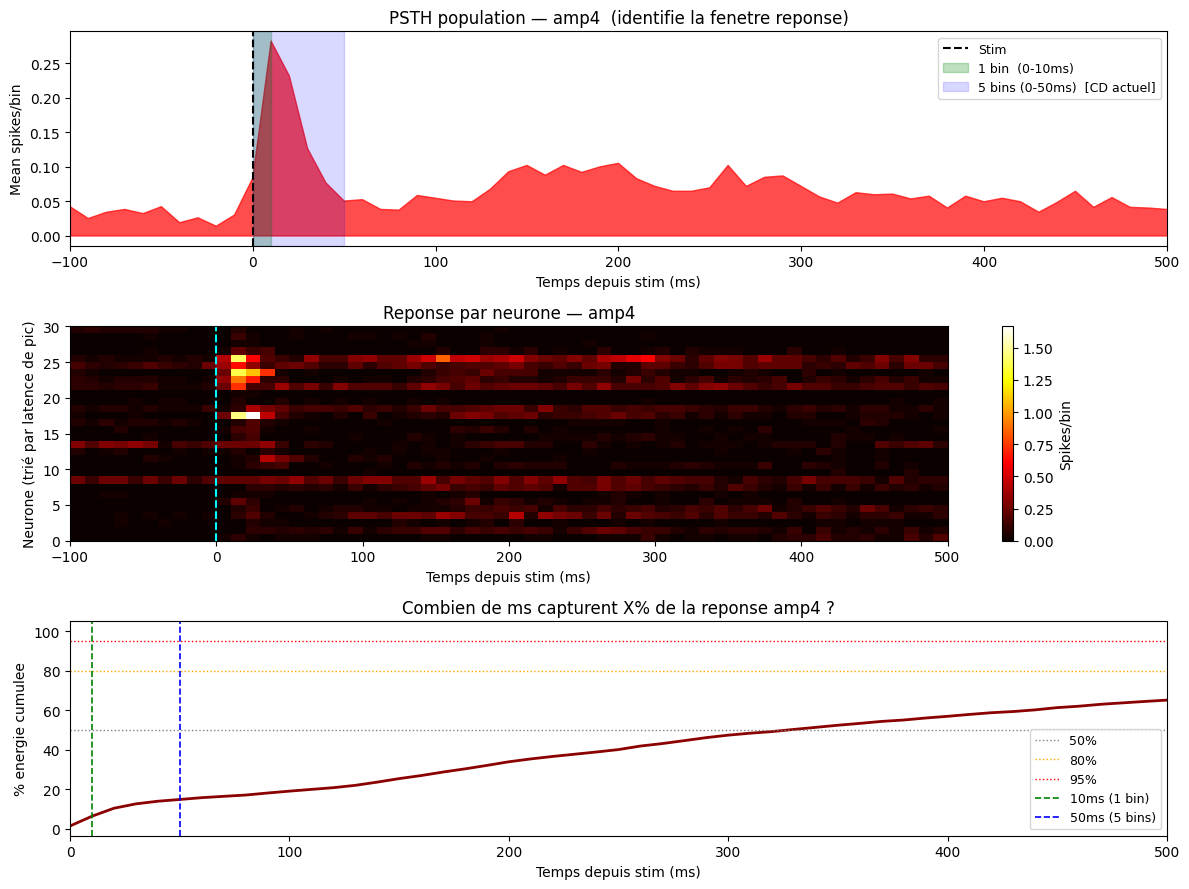

50% energie -> t = 330 ms  (bin 83, soit 34 bins apres stim)
80% energie -> t = 710 ms  (bin 121, soit 72 bins apres stim)
95% energie -> t = 920 ms  (bin 142, soit 93 bins apres stim)


In [10]:
# Diagnostic : quels bins sont actifs apres un stim amp4 ?
# -> choisir combien de bins inclure dans la Coding Direction

pre_bins_cd = pre_bins   # 50
time_ms = (np.arange(pre_bins + post_bins + 1) - pre_bins) * Bin_size * 1000  # en ms

mean_amp4_full = STM_by_amp[4]   # (n_neurons, W)
pop_mean_amp4  = mean_amp4_full.mean(axis=0)   # PSTH population

fig, axes = plt.subplots(3, 1, figsize=(12, 9))

# --- 1. PSTH population ---
ax = axes[0]
ax.fill_between(time_ms, pop_mean_amp4, alpha=0.7, color='red')
ax.axvline(0, color='black', linestyle='--', lw=1.5, label='Stim')
ax.axvspan(0, 10,  alpha=0.25, color='green', label='1 bin  (0-10ms)')
ax.axvspan(0, 50,  alpha=0.15, color='blue',  label='5 bins (0-50ms)  [CD actuel]')
ax.set_xlim(-100, 500)
ax.set_xlabel('Temps depuis stim (ms)')
ax.set_ylabel('Mean spikes/bin')
ax.set_title('PSTH population — amp4  (identifie la fenetre reponse)')
ax.legend(fontsize=9)

# --- 2. Heatmap par neurone ---
resp_post = mean_amp4_full[:, pre_bins_cd:pre_bins_cd + 30]   # 0-300ms
sort_cd   = np.argsort(np.argmax(resp_post, axis=1))
win_slice = slice(pre_bins_cd - 10, pre_bins_cd + 50)          # -100ms à +500ms
im = axes[1].imshow(mean_amp4_full[sort_cd, win_slice],
                    aspect='auto', cmap='hot',
                    extent=[-100, 500, 0, mean_amp4_full.shape[0]])
axes[1].axvline(0, color='cyan', linestyle='--', lw=1.5)
axes[1].set_xlabel('Temps depuis stim (ms)')
axes[1].set_ylabel('Neurone (trié par latence de pic)')
axes[1].set_title('Reponse par neurone — amp4')
plt.colorbar(im, ax=axes[1], label='Spikes/bin')

# --- 3. Energie cumulee post-stim ---
energy = pop_mean_amp4[pre_bins_cd:]
cum_e  = np.cumsum(energy) / (energy.sum() + 1e-12)
t_post = time_ms[pre_bins_cd:]

axes[2].plot(t_post, cum_e * 100, color='darkred', lw=2)
for pct, col in [(50, 'gray'), (80, 'orange'), (95, 'red')]:
    axes[2].axhline(pct, color=col, linestyle=':', lw=1, label=f'{pct}%')
axes[2].axvline(10,  color='green', linestyle='--', lw=1.2, label='10ms (1 bin)')
axes[2].axvline(50,  color='blue',  linestyle='--', lw=1.2, label='50ms (5 bins)')
axes[2].set_xlim(0, 500)
axes[2].set_xlabel('Temps depuis stim (ms)')
axes[2].set_ylabel('% energie cumulee')
axes[2].set_title('Combien de ms capturent X% de la reponse amp4 ?')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Imprimer les seuils
for pct in [50, 80, 95]:
    idx = np.where(cum_e >= pct / 100)[0]
    if len(idx) > 0:
        print(f"{pct}% energie -> t = {t_post[idx[0]]:.0f} ms  (bin {pre_bins_cd + idx[0]}, soit {idx[0]+1} bins apres stim)")

# TEST CODING DIRECTION 1BIN (50:51)

CD_1b norm: 0.9999999


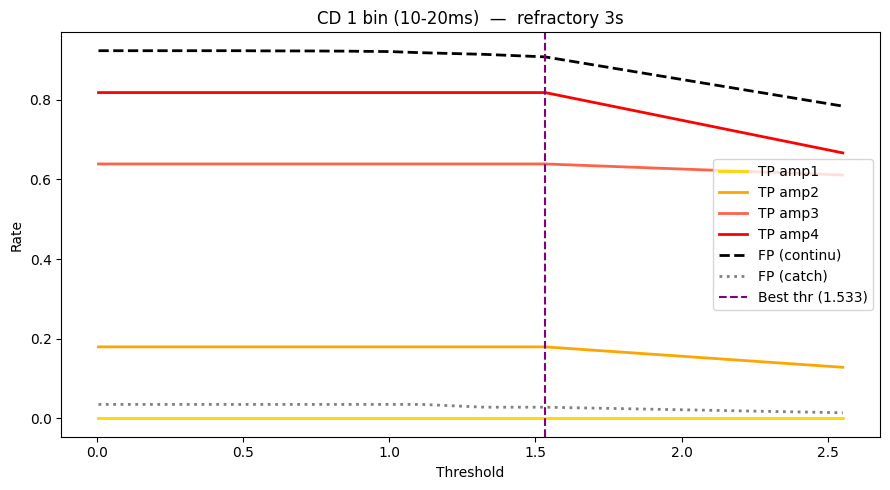


Best threshold = 1.5332
Total detections : 618  |  FP absolus : 561  |  FP rate : 0.91
  TP amp1 :   0 / 38  (rate = 0.00)
  TP amp2 :   7 / 39  (rate = 0.18)
  TP amp3 :  23 / 36  (rate = 0.64)
  TP amp4 :  27 / 33  (rate = 0.82)


In [11]:
# CD avec 1 bin (10-20ms apres stim, bin 51:52)
# Refractory 3 secondes : amp4 est rare, on ne veut pas voir
# plusieurs detections se suivre apres un seul evenement.

# --- CD 1 bin ---
PV_Stim_1b  = STM_by_amp[4][:, 51:52].mean(axis=1) 
PV_Catch_1b = CATCH_MTRX[:, 51:52].mean(axis=1)
CD_1b = PV_Stim_1b - PV_Catch_1b
CD_1b = CD_1b / (np.linalg.norm(CD_1b) + 1e-12)
print("CD_1b norm:", np.linalg.norm(CD_1b))

# --- Score instantane (1 bin) ---
score_1b = CD_1b @ AP_Bin_Matrx   # (n_bins,)
t_sig_1b = np.arange(len(score_1b)) * Bin_size

refractory = 3.0   # verrou 5 secondes apres chaque detection

# --- Sweep de threshold ---
in_range_1b = (t_sig_1b >= t_start) & (t_sig_1b <= t_end)
ths_1b      = np.percentile(score_1b[in_range_1b], np.linspace(50, 99.9, 80))

tp_1b   = {a: [] for a in amps_stim}
fp_co1b = []
fp_ca1b = []

for thr in ths_1b:
    det_t = detect_peaks(score_1b, t_sig_1b, thr, refractory, Bin_size, t_start, t_end)
    n_det = max(len(det_t), 1)

    in_win_any = np.zeros(len(det_t), dtype=bool)
    for st in all_stim_times:
        in_win_any |= (det_t >= st) & (det_t <= st + tol_post)
    fp_co1b.append(np.sum(~in_win_any) / n_det)

    hits_catch = sum(
        np.any((det_t >= st) & (det_t <= st + tol_post))
        for st in Catch_times
    )
    fp_ca1b.append(hits_catch / max(n_catch_trials, 1))

    for a in amps_stim:
        hits = sum(
            np.any((det_t >= st) & (det_t <= st + tol_post))
            for st in Stim_times_by_amp[a]
        )
        tp_1b[a].append(hits / max(len(Stim_times_by_amp[a]), 1))

tp_1b   = {a: np.array(tp_1b[a]) for a in amps_stim}
fp_co1b = np.array(fp_co1b)
fp_ca1b = np.array(fp_ca1b)

# --- Meilleur threshold : max(TP4 - FP), min 10 det, TP4 > 0 ---
best_i1b = None
best_sc1b = -np.inf
for i, thr in enumerate(ths_1b):
    det_t = detect_peaks(score_1b, t_sig_1b, thr, refractory, Bin_size, t_start, t_end)
    if len(det_t) >= 10 and tp_1b[4][i] > 0:
        sc = tp_1b[4][i] - fp_co1b[i]
        if sc > best_sc1b:
            best_sc1b = sc
            best_i1b  = i
best_thr_1b = ths_1b[best_i1b] if best_i1b is not None else ths_1b[40]

# --- Plot ---
plt.figure(figsize=(9, 5))
for a in amps_stim:
    plt.plot(ths_1b, tp_1b[a], color=colors_amp[a], lw=2, label=f"TP amp{a}")
plt.plot(ths_1b, fp_co1b, color="black", lw=2, linestyle="--", label="FP (continu)")
plt.plot(ths_1b, fp_ca1b, color="gray",  lw=2, linestyle=":",  label="FP (catch)")
plt.axvline(best_thr_1b, color="purple", linestyle="--", lw=1.5,
            label=f"Best thr ({best_thr_1b:.3f})")
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("CD 1 bin (10-20ms)  —  refractory 3s")
plt.legend()
plt.tight_layout()
plt.show()

# --- Stats au meilleur threshold ---
det_t = detect_peaks(score_1b, t_sig_1b, best_thr_1b, refractory, Bin_size, t_start, t_end)
in_win_any = np.zeros(len(det_t), dtype=bool)
for st in all_stim_times:
    in_win_any |= (det_t >= st) & (det_t <= st + tol_post)
n_fp_1b = int(np.sum(~in_win_any))

print(f"\nBest threshold = {best_thr_1b:.4f}")
print(f"Total detections : {len(det_t)}  |  FP absolus : {n_fp_1b}  |  FP rate : {n_fp_1b/max(len(det_t),1):.2f}")
for a in amps_stim:
    hits = sum(np.any((det_t >= st) & (det_t <= st + tol_post))
               for st in Stim_times_by_amp[a])
    print(f"  TP amp{a} : {hits:3d} / {len(Stim_times_by_amp[a])}  (rate = {hits/max(len(Stim_times_by_amp[a]),1):.2f})")

# MEME TECHNIQUE MAIS CD2 50ms-60ms

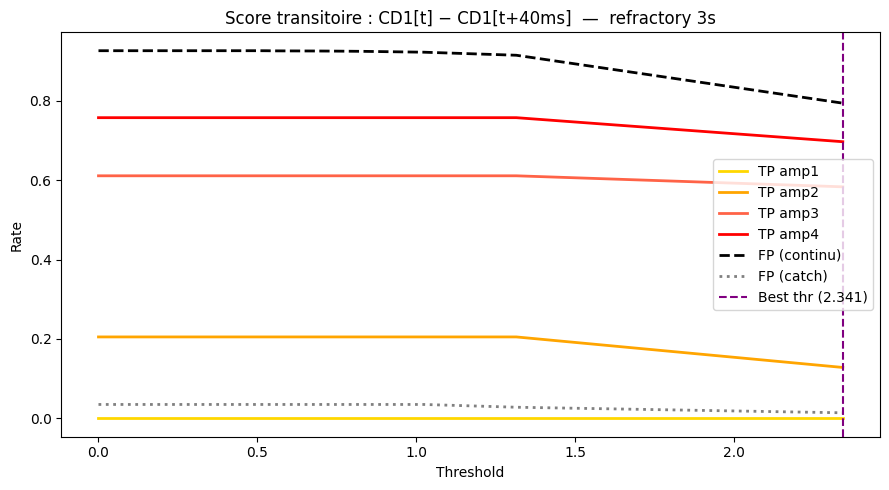

delta = 4 bins = 40ms
Best threshold = 2.3415
Total detections : 238  |  FP absolus : 189  |  FP rate : 0.79
  TP amp1 :   0 / 38  (rate = 0.00)
  TP amp2 :   5 / 39  (rate = 0.13)
  TP amp3 :  21 / 36  (rate = 0.58)
  TP amp4 :  23 / 33  (rate = 0.70)


In [12]:
# Score transitoire : CD1[t] - CD1[t + delta]
#
# Idee : un vrai stim = burst BREF -> score CD1 fort a t, retombe a t+40ms
#        un UP state  = bloc SOUTENU -> score CD1 fort a t ET encore fort a t+40ms
#
# score_transient[t] = score1[t] - score1[t + delta]
# -> haut si reponse breve (stim)      : score monte puis retombe vite
# -> proche de 0 si plateau (UP state) : score reste eleve, difference ≈ 0

# --- CD1 : bin 51:52 (10-20ms) ---
PV_Stim_1  = STM_by_amp[4][:, 51:52].mean(axis=1)
PV_Catch_1 = CATCH_MTRX[:, 51:52].mean(axis=1)
CD1 = PV_Stim_1 - PV_Catch_1
CD1 = CD1 / (np.linalg.norm(CD1) + 1e-12)

score1   = CD1 @ AP_Bin_Matrx          # (n_bins,)
t_sig1   = np.arange(len(score1)) * Bin_size

# --- Score transitoire ---
delta_bins = 4    # 40ms : assez long pour que le stim soit retombe, assez court pour rester dans l'UP state
score_trans = np.zeros_like(score1)
score_trans[:-delta_bins] = score1[:-delta_bins] - score1[delta_bins:]
# (les derniers delta_bins restent a 0)

t_sig_trans    = t_sig1
refractory_tr  = 3.0

# --- Sweep de threshold ---
in_range_tr = (t_sig_trans >= t_start) & (t_sig_trans <= t_end)
ths_tr      = np.percentile(score_trans[in_range_tr], np.linspace(50, 99.9, 80))

tp_tr    = {a: [] for a in amps_stim}
fp_co_tr = []
fp_ca_tr = []

for thr in ths_tr:
    det_t = detect_peaks(score_trans, t_sig_trans, thr, refractory_tr, Bin_size, t_start, t_end)
    n_det = max(len(det_t), 1)

    in_win_any = np.zeros(len(det_t), dtype=bool)
    for st in all_stim_times:
        in_win_any |= (det_t >= st) & (det_t <= st + tol_post)
    fp_co_tr.append(np.sum(~in_win_any) / n_det)

    hits_catch = sum(
        np.any((det_t >= st) & (det_t <= st + tol_post))
        for st in Catch_times
    )
    fp_ca_tr.append(hits_catch / max(n_catch_trials, 1))

    for a in amps_stim:
        hits = sum(
            np.any((det_t >= st) & (det_t <= st + tol_post))
            for st in Stim_times_by_amp[a]
        )
        tp_tr[a].append(hits / max(len(Stim_times_by_amp[a]), 1))

tp_tr    = {a: np.array(tp_tr[a]) for a in amps_stim}
fp_co_tr = np.array(fp_co_tr)
fp_ca_tr = np.array(fp_ca_tr)

# --- Meilleur threshold ---
best_i_tr  = None
best_sc_tr = -np.inf
for i, thr in enumerate(ths_tr):
    det_t = detect_peaks(score_trans, t_sig_trans, thr, refractory_tr, Bin_size, t_start, t_end)
    if len(det_t) >= 10 and tp_tr[4][i] > 0:
        sc = tp_tr[4][i] - fp_co_tr[i]
        if sc > best_sc_tr:
            best_sc_tr = sc
            best_i_tr  = i
best_thr_tr = ths_tr[best_i_tr] if best_i_tr is not None else ths_tr[40]

# --- Plot ---
plt.figure(figsize=(9, 5))
for a in amps_stim:
    plt.plot(ths_tr, tp_tr[a], color=colors_amp[a], lw=2, label=f"TP amp{a}")
plt.plot(ths_tr, fp_co_tr, color="black", lw=2, linestyle="--", label="FP (continu)")
plt.plot(ths_tr, fp_ca_tr, color="gray",  lw=2, linestyle=":",  label="FP (catch)")
plt.axvline(best_thr_tr, color="purple", linestyle="--", lw=1.5,
            label=f"Best thr ({best_thr_tr:.3f})")
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title(f"Score transitoire : CD1[t] − CD1[t+{delta_bins*10}ms]  —  refractory {refractory_tr:.0f}s")
plt.legend()
plt.tight_layout()
plt.show()

# --- Stats au meilleur threshold ---
det_t = detect_peaks(score_trans, t_sig_trans, best_thr_tr, refractory_tr, Bin_size, t_start, t_end)
in_win_any = np.zeros(len(det_t), dtype=bool)
for st in all_stim_times:
    in_win_any |= (det_t >= st) & (det_t <= st + tol_post)
n_fp_tr = int(np.sum(~in_win_any))

print(f"delta = {delta_bins} bins = {delta_bins*10}ms")
print(f"Best threshold = {best_thr_tr:.4f}")
print(f"Total detections : {len(det_t)}  |  FP absolus : {n_fp_tr}  |  FP rate : {n_fp_tr/max(len(det_t),1):.2f}")
for a in amps_stim:
    hits = sum(np.any((det_t >= st) & (det_t <= st + tol_post))
               for st in Stim_times_by_amp[a])
    print(f"  TP amp{a} : {hits:3d} / {len(Stim_times_by_amp[a])}  (rate = {hits/max(len(Stim_times_by_amp[a]),1):.2f})")

# DETECTION EN 2 ETAPES : CD bin 51:52 + similarite multi-bin (45-60)

In [ ]:
# Detection 2 etapes :
# 1. Detecter les peaks sur CD (bin 51:52), refractory 200ms
# 2. Pour chaque peak detecte a t_det, comparer l'activite dans la fenetre
#    [t_det-50ms, t_det+100ms] (bins 45:61) au template amp4 bin par bin
#    -> similarite agregee = moyenne des cosine similarities sur les 16 bins
# 3. Filtrer les peaks selon ce score de similarite multi-bin

bins_template = np.arange(45, 61)   # 16 bins : -50ms a +100ms autour du stim
ref_bin       = 50                  # bin 50 = t=0 (onset stim)

# --- Precompute : template normalise pour chaque bin ---
templates_norm = []
for b in bins_template:
    t_b = STM_by_amp[4][:, b].astype(np.float64)
    t_b = t_b / (np.linalg.norm(t_b) + 1e-12)
    templates_norm.append(t_b)
templates_norm = np.array(templates_norm)   # (16, n_neurons)

# --- CD1 (bin 51:52) et score ---
PV_Stim_mb  = STM_by_amp[4][:, 51:52].mean(axis=1)
PV_Catch_mb = CATCH_MTRX[:, 51:52].mean(axis=1)
CD_mb  = PV_Stim_mb - PV_Catch_mb
CD_mb  = CD_mb / (np.linalg.norm(CD_mb) + 1e-12)
score_mb   = CD_mb @ AP_Bin_Matrx
t_sig_mb   = np.arange(len(score_mb)) * Bin_size

in_range_mb = (t_sig_mb >= t_start) & (t_sig_mb <= t_end)
ths_mb      = np.percentile(score_mb[in_range_mb], np.linspace(50, 99.9, 80))

# --- Fonction : similarite multi-bin pour un batch de peaks ---
def multibin_sim(det_t, AP_Bin_Matrx, AP_Bin_Resolution, templates_norm, bins_template, ref_bin):
    """
    Pour chaque peak detecte, calcule la moyenne des cosine similarities
    entre l'activite observee et le template amp4, sur chaque bin de bins_template.
    """
    n_det = len(det_t)
    if n_det == 0:
        return np.array([])
    pts   = np.round(det_t * AP_Bin_Resolution).astype(int)
    sims  = np.zeros(n_det)
    count = np.zeros(n_det)

    for i, b in enumerate(bins_template):
        offset  = b - ref_bin
        pts_b   = pts + offset
        valid   = (pts_b >= 0) & (pts_b < AP_Bin_Matrx.shape[1])
        if not valid.any():
            continue
        vecs        = AP_Bin_Matrx[:, pts_b[valid]].astype(np.float64)   # (n_neurons, n_valid)
        norms       = np.linalg.norm(vecs, axis=0) + 1e-12
        vecs_norm   = vecs / norms                                         # (n_neurons, n_valid)
        sims[valid] += templates_norm[i] @ vecs_norm                      # cosine sim par peak
        count[valid] += 1

    return sims / np.maximum(count, 1)   # moyenne sur les bins valides

# --- Sweep CD threshold + filtre similarite ---
sim_thresholds = [0.3, 0.4, 0.5, 0.6]

fig, axes = plt.subplots(1, len(sim_thresholds), figsize=(6 * len(sim_thresholds), 5), sharey=True)

for ax, sim_thr in zip(axes, sim_thresholds):
    tp_c  = {a: [] for a in amps_stim}
    fp_co = []
    fp_ca = []

    for thr in ths_mb:
        det_t = detect_peaks(score_mb, t_sig_mb, thr, 0.2, Bin_size, t_start, t_end)

        # Filtre multi-bin
        if len(det_t) > 0:
            sims  = multibin_sim(det_t, AP_Bin_Matrx, AP_Bin_Resolution,
                                 templates_norm, bins_template, ref_bin)
            det_t = det_t[sims >= sim_thr]

        n_det = max(len(det_t), 1)

        in_win_any = np.zeros(len(det_t), dtype=bool)
        for st in all_stim_times:
            in_win_any |= (det_t >= st) & (det_t <= st + tol_post)
        fp_co.append(np.sum(~in_win_any) / n_det)

        hits_catch = sum(np.any((det_t >= st) & (det_t <= st + tol_post))
                         for st in Catch_times)
        fp_ca.append(hits_catch / max(n_catch_trials, 1))

        for a in amps_stim:
            hits = sum(np.any((det_t >= st) & (det_t <= st + tol_post))
                       for st in Stim_times_by_amp[a])
            tp_c[a].append(hits / max(len(Stim_times_by_amp[a]), 1))

    for a in amps_stim:
        ax.plot(ths_mb, tp_c[a], color=colors_amp[a], lw=2, label=f"TP amp{a}")
    ax.plot(ths_mb, fp_co, color="black", lw=2, linestyle="--", label="FP (continu)")
    ax.plot(ths_mb, fp_ca, color="gray",  lw=2, linestyle=":",  label="FP (catch)")
    ax.set_xlabel("CD threshold (bin 51:52)")
    ax.set_ylabel("Rate")
    ax.set_title(f"Sim multi-bin >= {sim_thr:.1f}")
    ax.legend(fontsize=8)

plt.suptitle("CD (bin 51:52)  +  similarite multi-bin amp4 (bins 45-60, moyenne cosine sur 16 bins)")
plt.tight_layout()
plt.show()

# --- Distribution des similarites : TP amp4 vs FP au threshold median ---
thr_mid = np.median(ths_mb)
det_all = detect_peaks(score_mb, t_sig_mb, thr_mid, 0.2, Bin_size, t_start, t_end)
sims_all = multibin_sim(det_all, AP_Bin_Matrx, AP_Bin_Resolution,
                        templates_norm, bins_template, ref_bin)

in_win_amp4 = np.zeros(len(det_all), dtype=bool)
for st in Stim_times_by_amp[4]:
    in_win_amp4 |= (det_all >= st) & (det_all <= st + tol_post)

plt.figure(figsize=(8, 4))
plt.hist(sims_all[in_win_amp4],  bins=30, alpha=0.6, color='red',   label=f'TP amp4 (n={in_win_amp4.sum()})',  density=True)
plt.hist(sims_all[~in_win_amp4], bins=30, alpha=0.5, color='black', label=f'FP      (n={(~in_win_amp4).sum()})', density=True)
plt.xlabel("Similarite multi-bin moyenne (cosine, bins 45-60)")
plt.ylabel("Densite")
plt.title("Distribution similarite : TP amp4 vs FP — seuil CD = median")
plt.legend()
plt.tight_layout()
plt.show()

# COMPARAISON ACTIVITE MOYENNE HIT VS MISS, PR CHAQUE AMPLITUDE

amp1 — hits: 8, misses: 30
amp2 — hits: 20, misses: 19
amp3 — hits: 34, misses: 2
amp4 — hits: 31, misses: 2


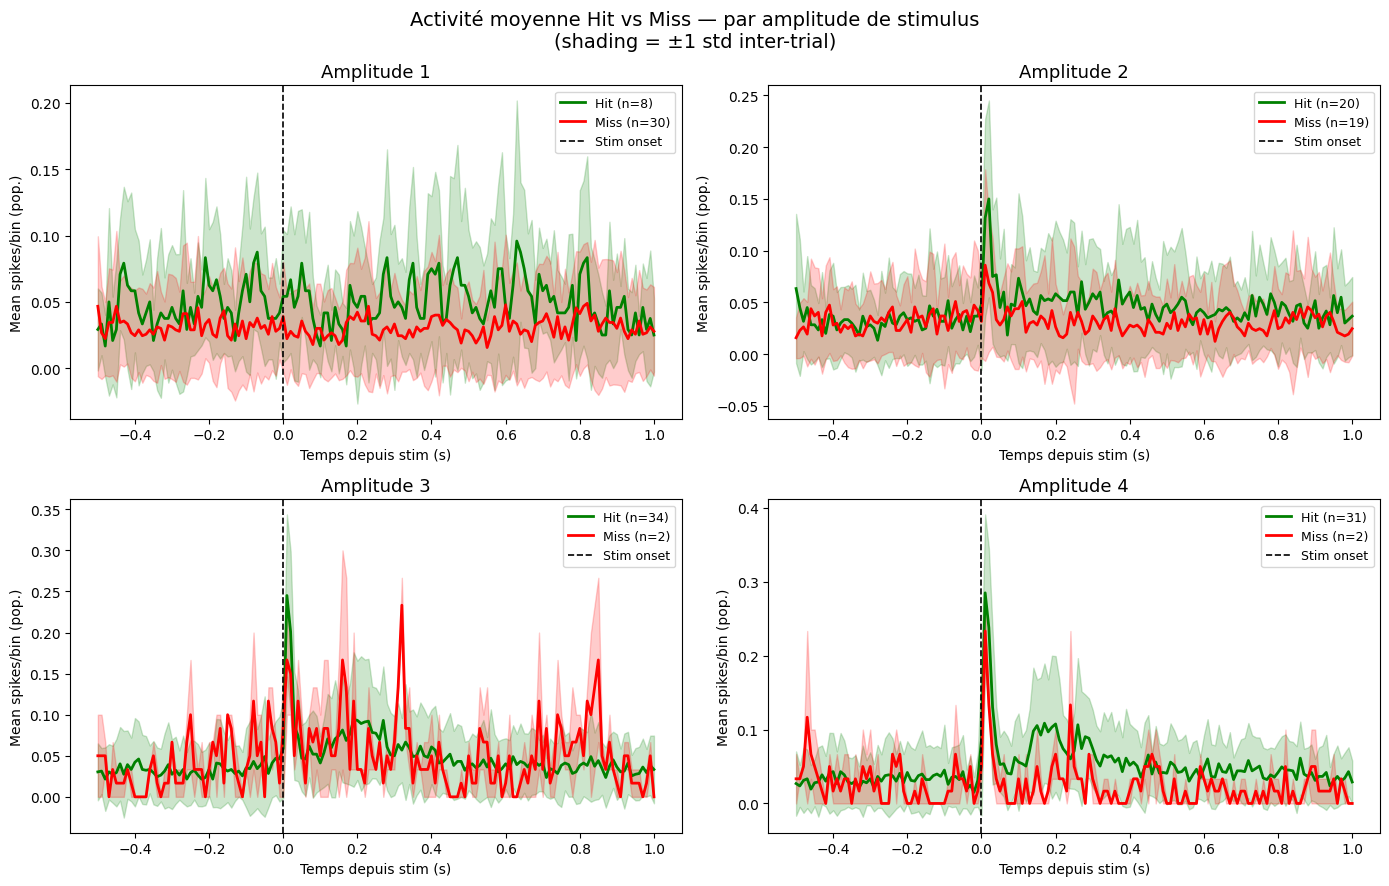

In [33]:

# Comparaison activité moyenne hit vs miss par amplitude
# Hit = lick_flag==1, Miss = lick_flag==0
# On utilise event_triggered_matrix (déjà définie) pour extraire (n_trials, n_neurons, W)
# puis on moyenne sur les neurones -> PSTH population par trial, ensuite mean ± std sur les trials

stim_sel_hm = tr["whisker_stim"].astype(bool) & tr["whisker_stim_time"].notna()

hit_times_by_amp  = {}
miss_times_by_amp = {}

for a in amps_stim:
    sub = tr[stim_sel_hm & (tr["whisker_stim_amplitude"] == a)]
    hit_times_by_amp[a]  = np.sort(sub.loc[sub["lick_flag"] == 1.0, "whisker_stim_time"].to_numpy())
    miss_times_by_amp[a] = np.sort(sub.loc[sub["lick_flag"] == 0.0, "whisker_stim_time"].to_numpy())
    print(f"amp{a} — hits: {len(hit_times_by_amp[a])}, misses: {len(miss_times_by_amp[a])}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=False)
axes = axes.flatten()

for idx, a in enumerate(amps_stim):
    ax = axes[idx]

    # Extraire matrices (n_trials, n_neurons, W)
    mat_hit,  n_hit  = event_triggered_matrix(AP_Bin_Matrx, hit_times_by_amp[a],
                                               AP_Bin_Resolution, pre_bins, post_bins)
    mat_miss, n_miss = event_triggered_matrix(AP_Bin_Matrx, miss_times_by_amp[a],
                                               AP_Bin_Resolution, pre_bins, post_bins)

    # Moyenne sur les neurones -> (n_trials, W), puis mean ± std sur les trials
    if mat_hit is not None and n_hit > 0:
        pop_hit   = mat_hit.mean(axis=1)            # (n_trials, W)
        mean_hit  = pop_hit.mean(axis=0)
        std_hit   = pop_hit.std(axis=0)
        ax.plot(time_axis, mean_hit, color="green", lw=2, label=f"Hit (n={n_hit})")
        ax.fill_between(time_axis,
                        mean_hit - std_hit, mean_hit + std_hit,
                        color="green", alpha=0.2)

    if mat_miss is not None and n_miss > 0:
        pop_miss  = mat_miss.mean(axis=1)           # (n_trials, W)
        mean_miss = pop_miss.mean(axis=0)
        std_miss  = pop_miss.std(axis=0)
        ax.plot(time_axis, mean_miss, color="red", lw=2, label=f"Miss (n={n_miss})")
        ax.fill_between(time_axis,
                        mean_miss - std_miss, mean_miss + std_miss,
                        color="red", alpha=0.2)

    ax.axvline(0, color="black", linestyle="--", lw=1.2, label="Stim onset")
    ax.set_title(f"Amplitude {a}", fontsize=13)
    ax.set_xlabel("Temps depuis stim (s)")
    ax.set_ylabel("Mean spikes/bin (pop.)")
    ax.legend(fontsize=9)

fig.suptitle("Activité moyenne Hit vs Miss — par amplitude de stimulus\n(shading = ±1 std inter-trial)", fontsize=14)
plt.tight_layout()
plt.show()


# NOUVELLES DONNEES: JAWTRACE ET PIEZO

JawTrace   : 289000 samples,   26.3 – 3882.9 s
PiezoLick  : 5094295 samples, 0.0 – 5094.3 s


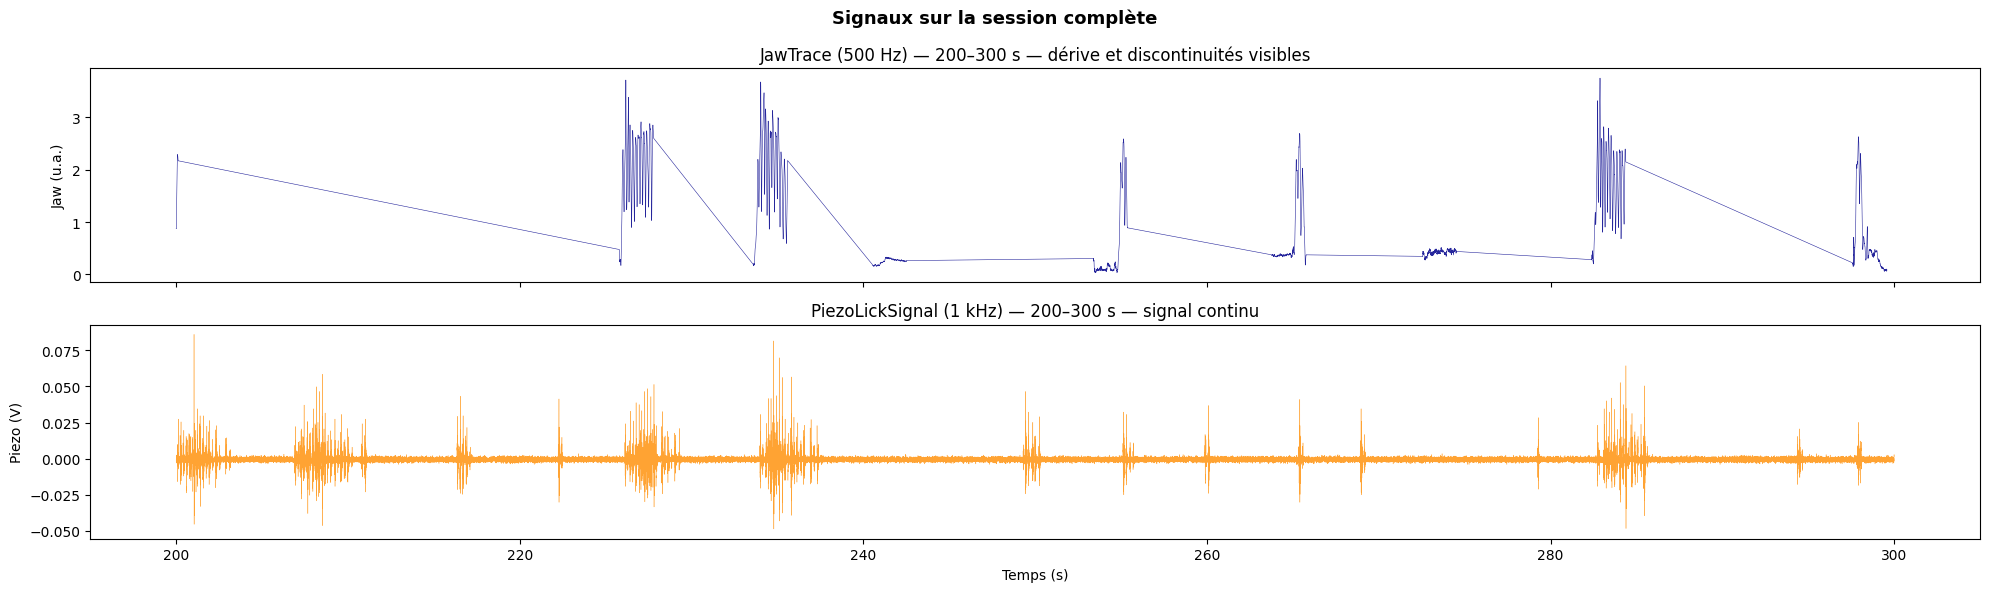

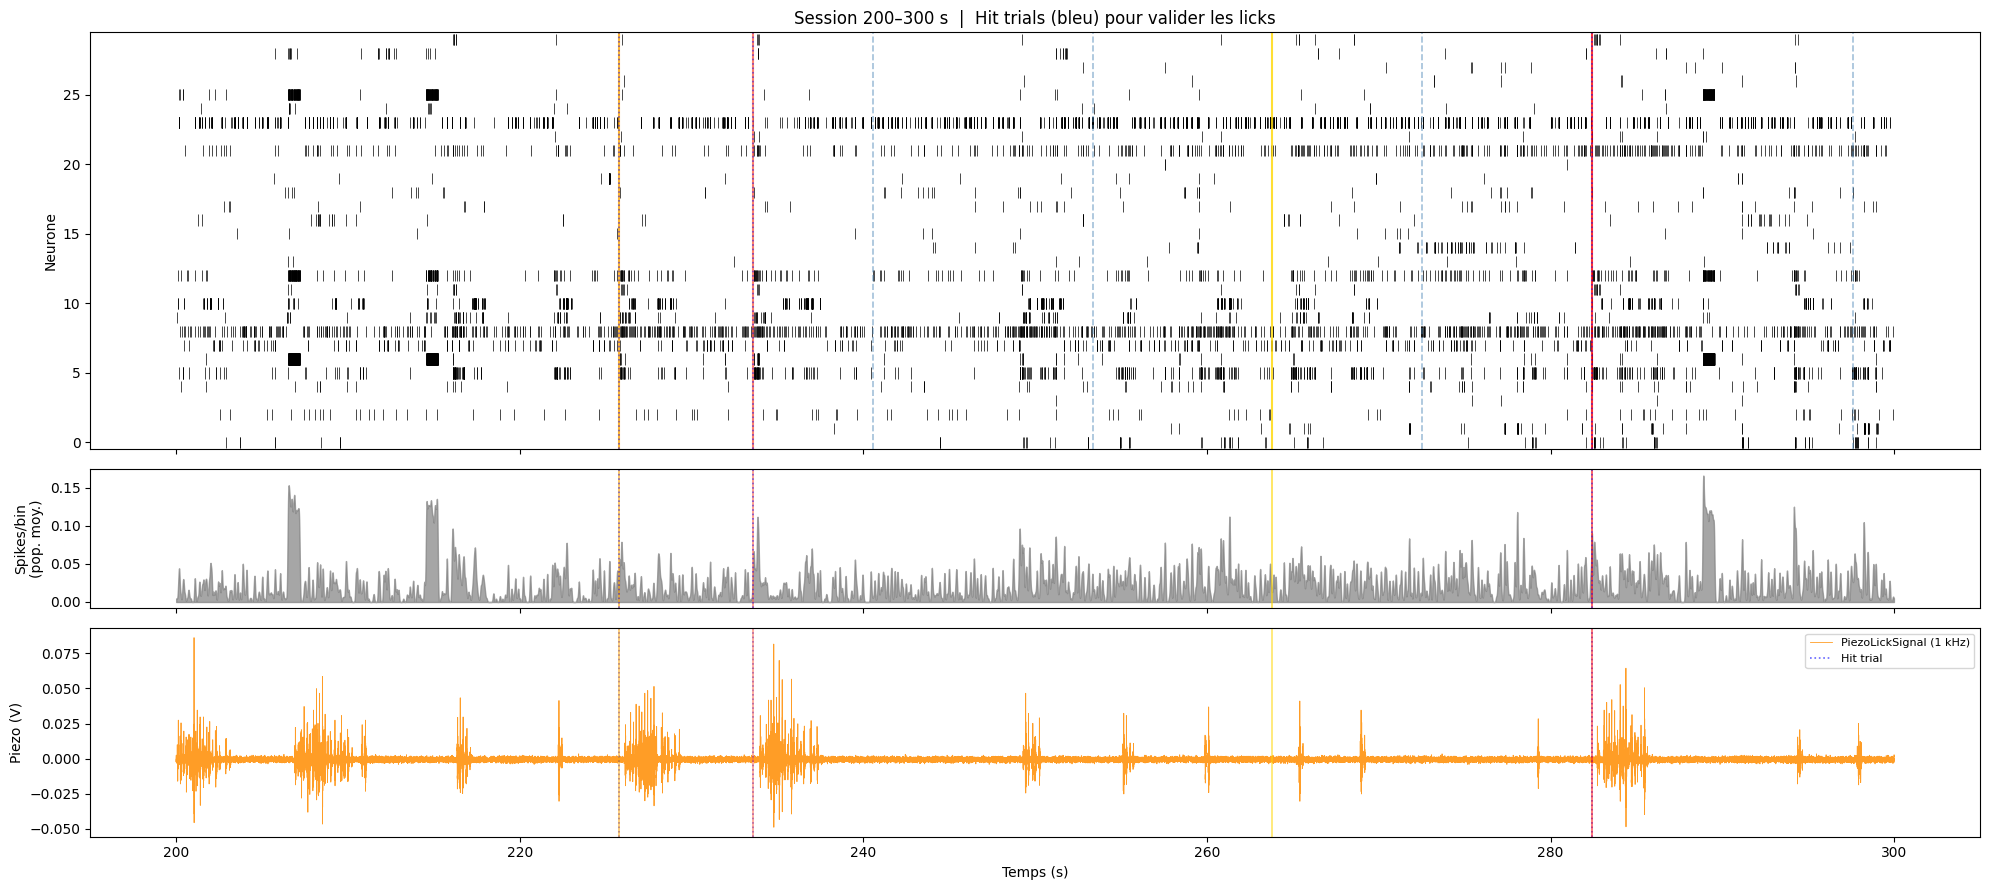

In [41]:
# JawTrace et PiezoLickSignal

from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

# data
with NWBHDF5IO(path, "r") as io:
    nwb_beh = io.read()
    beh = nwb_beh.processing["behavior"]

    jaw_obj  = beh["BehavioralTimeSeries"]["JawTrace"]
    jaw_data = np.array(jaw_obj.data, dtype=np.float32)
    jaw_ts   = np.array(jaw_obj.timestamps)

    piezo_obj  = beh["BehavioralTimeSeries"]["PiezoLickSignal"]
    piezo_data = np.array(piezo_obj.data, dtype=np.float32)
    piezo_ts   = np.array(piezo_obj.timestamps)

    confirmed_lick_ts = np.array(beh["BehavioralEvents"]["jaw_dlc_licks"].timestamps)

t0_vis, t1_vis = 200.0, 300.0  # fenêtre de visualisation

print(f"JawTrace   : {len(jaw_ts)} samples,   {jaw_ts[0]:.1f} – {jaw_ts[-1]:.1f} s")
print(f"PiezoLick  : {len(piezo_ts)} samples, {piezo_ts[0]:.1f} – {piezo_ts[-1]:.1f} s")

# FIGURE 1 : JawTrace vs Piezo, seulement sur la time window du haut
fig, axes = plt.subplots(2, 1, figsize=(20, 6), sharex=True)
fig.suptitle("Signaux sur la session complète", fontsize=13, fontweight="bold")

mask_jaw_win   = (jaw_ts   >= t0_vis) & (jaw_ts   <= t1_vis)
mask_piezo_win = (piezo_ts >= t0_vis) & (piezo_ts <= t1_vis)

axes[0].plot(jaw_ts[mask_jaw_win], jaw_data[mask_jaw_win], color="darkblue", lw=0.4, alpha=0.85)
axes[0].set_ylabel("Jaw (u.a.)")
axes[0].set_title(f"JawTrace (500 Hz) — {t0_vis:.0f}–{t1_vis:.0f} s — dérive et discontinuités visibles")

axes[1].plot(piezo_ts[mask_piezo_win], piezo_data[mask_piezo_win], color="darkorange", lw=0.3, alpha=0.8)
axes[1].set_ylabel("Piezo (V)")
axes[1].set_title(f"PiezoLickSignal (1 kHz) — {t0_vis:.0f}–{t1_vis:.0f} s — signal continu")
axes[1].set_xlabel("Temps (s)")

plt.tight_layout()
plt.show()

# FIGURE 2 : Zoom — Neurones + Firing rate + Piezo + Hit trials

mask_piezo  = (piezo_ts >= t0_vis) & (piezo_ts <= t1_vis)
t_piezo_win = piezo_ts[mask_piezo]
sig_piezo   = piezo_data[mask_piezo]

b0, b1   = int(t0_vis * AP_Bin_Resolution), int(t1_vis * AP_Bin_Resolution)
t_rate   = np.arange(b0, b1) * Bin_size
rate_sm  = gaussian_filter1d(AP_Bin_Matrx[:, b0:b1].mean(axis=0), sigma=3)

# Hit trial times (toutes amplitudes)
all_hit_times = np.concatenate([hit_times_by_amp[a] for a in amps_stim])
hit_win = all_hit_times[(all_hit_times >= t0_vis) & (all_hit_times <= t1_vis)]

colors_amp_vis = {1: "gold", 2: "orange", 3: "tomato", 4: "red"}

fig, axes = plt.subplots(3, 1, figsize=(20, 9), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1, 1.5]})

# Raster
ax = axes[0]
for n, st in enumerate(spike_times):
    spk = st[(st >= t0_vis) & (st <= t1_vis)]
    ax.vlines(spk, n - 0.4, n + 0.4, linewidth=0.5, color="black")
for a in amps_stim:
    for st in Stim_times_by_amp[a]:
        if t0_vis <= st <= t1_vis:
            ax.axvline(st, color=colors_amp_vis[a], alpha=0.8, lw=1.5)
for ct in Catch_times:
    if t0_vis <= ct <= t1_vis:
        ax.axvline(ct, color="steelblue", alpha=0.5, lw=1.2, linestyle="--")
for ht in hit_win:
    ax.axvline(ht, color="blue", alpha=0.5, lw=1.2, linestyle=":")
ax.set_ylabel("Neurone")
ax.set_title(f"Session {t0_vis:.0f}–{t1_vis:.0f} s  |  Hit trials (bleu) pour valider les licks")
ax.set_ylim(-0.5, len(spike_times) - 0.5)

# Firing rate
ax2 = axes[1]
ax2.fill_between(t_rate, rate_sm, alpha=0.7, color="gray")
for a in amps_stim:
    for st in Stim_times_by_amp[a]:
        if t0_vis <= st <= t1_vis:
            ax2.axvline(st, color=colors_amp_vis[a], alpha=0.7, lw=1.2)
for ht in hit_win:
    ax2.axvline(ht, color="blue", alpha=0.5, lw=1.2, linestyle=":")
ax2.set_ylabel("Spikes/bin\n(pop. moy.)")

# Piezo
ax3 = axes[2]
ax3.plot(t_piezo_win, sig_piezo, color="darkorange", lw=0.6, alpha=0.85, label="PiezoLickSignal (1 kHz)")
for ht in hit_win:
    ax3.axvline(ht, color="blue", alpha=0.6, lw=1.2, linestyle=":", label="Hit trial")
for a in amps_stim:
    for st in Stim_times_by_amp[a]:
        if t0_vis <= st <= t1_vis:
            ax3.axvline(st, color=colors_amp_vis[a], alpha=0.6, lw=1.2)
handles, labels = ax3.get_legend_handles_labels()
ax3.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(),
           fontsize=8, loc="upper right")
ax3.set_ylabel("Piezo (V)")
ax3.set_xlabel("Temps (s)")

plt.tight_layout()
plt.show()


Licks confirmés (jaw_dlc_licks) : 289
Enveloppe aux vrais licks — mean=0.00159, std=0.00162, min=0.00075
Seuil utilisé (moyenne) : 0.00159
Licks détectés sur piezo (session entière) : 2946
Licks confirmés (jaw_dlc_licks) : 289


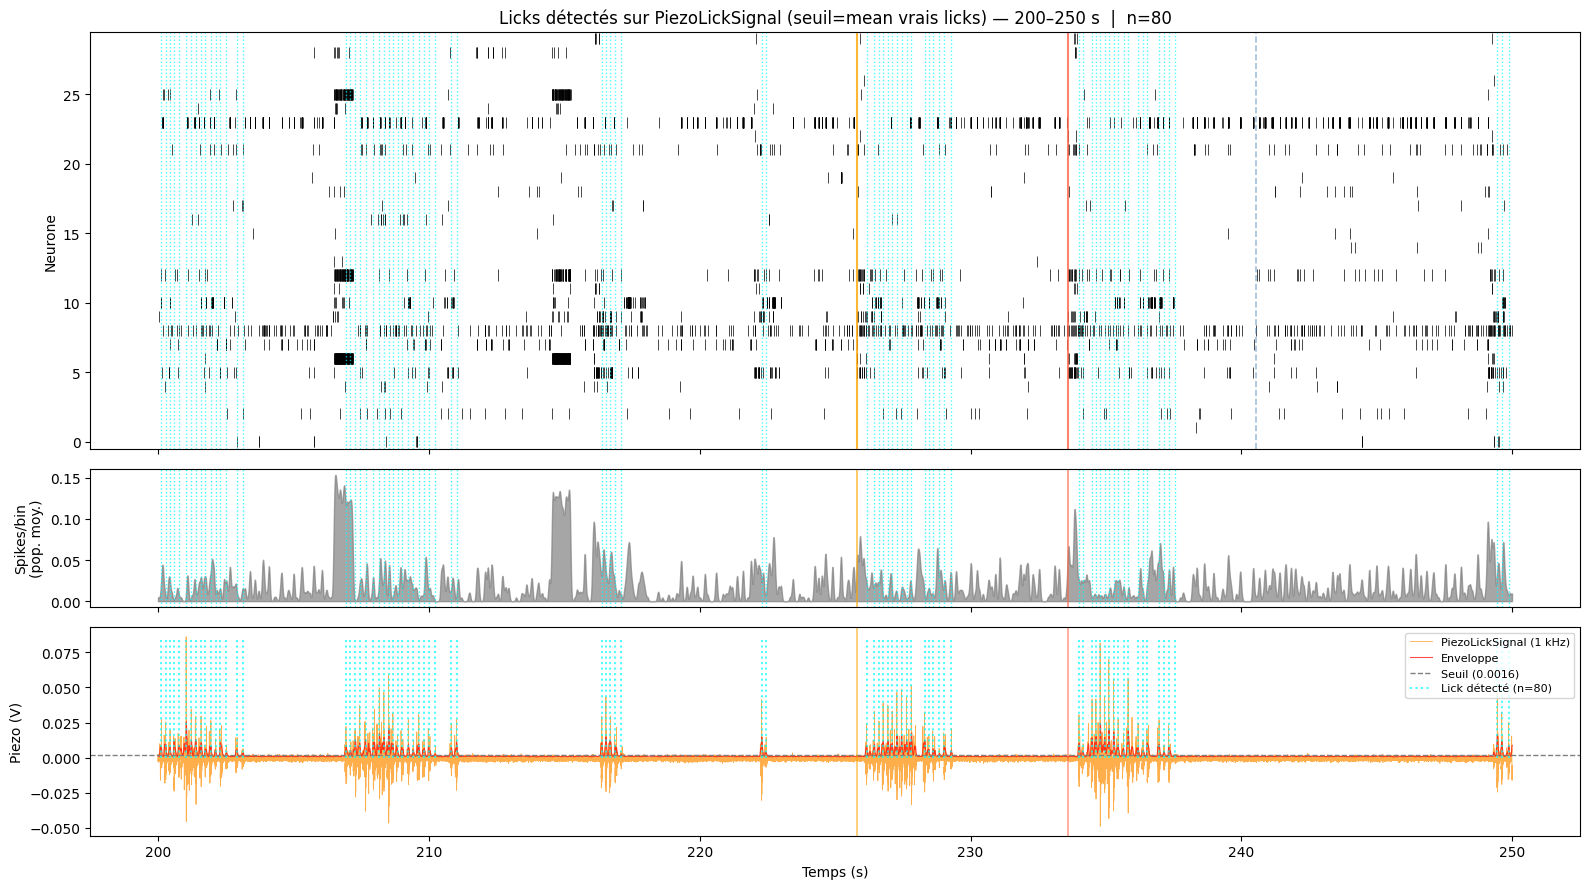

In [42]:
# Détection des licks sur le signal PiezoLickSignal complet
# Seuil = moyenne de l'enveloppe aux vrais lick times (jaw_dlc_licks)

from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

piezo_rate = 1000.0  # 1 kHz

# Enveloppe : rectification + lissage 10 ms
piezo_env = gaussian_filter1d(np.abs(piezo_data), sigma=int(0.01 * piezo_rate))

# Valeur de l'enveloppe à chaque lick confirmé (max dans ±50 ms)
half_win_p = int(0.05 * piezo_rate)
confirmed_peaks_p = []
for lt in confirmed_lick_ts:
    idx = np.searchsorted(piezo_ts, lt)
    i0  = max(0, idx - half_win_p)
    i1  = min(len(piezo_env) - 1, idx + half_win_p)
    confirmed_peaks_p.append(piezo_env[i0:i1].max())

confirmed_peaks_p = np.array(confirmed_peaks_p)

# Seuil = moyenne des pics aux vrais lick times
thr_piezo = confirmed_peaks_p.mean()

print(f"Licks confirmés (jaw_dlc_licks) : {len(confirmed_lick_ts)}")
print(f"Enveloppe aux vrais licks — mean={thr_piezo:.5f}, std={confirmed_peaks_p.std():.5f}, min={confirmed_peaks_p.min():.5f}")
print(f"Seuil utilisé (moyenne) : {thr_piezo:.5f}")

# Détection sur toute la session (réfractaire 150 ms)
min_dist_p = int(0.15 * piezo_rate)
peak_idx_p, _ = find_peaks(piezo_env, height=thr_piezo, distance=min_dist_p)
all_lick_times_piezo = piezo_ts[peak_idx_p]

print(f"Licks détectés sur piezo (session entière) : {len(all_lick_times_piezo)}")
print(f"Licks confirmés (jaw_dlc_licks) : {len(confirmed_lick_ts)}")

# fenetre de visu
t0_vis, t1_vis = 200.0, 250.0

mask_piezo  = (piezo_ts >= t0_vis) & (piezo_ts <= t1_vis)
t_piezo_win = piezo_ts[mask_piezo]
sig_piezo   = piezo_data[mask_piezo]

lick_win_p  = all_lick_times_piezo[(all_lick_times_piezo >= t0_vis) & (all_lick_times_piezo <= t1_vis)]

b0, b1   = int(t0_vis * AP_Bin_Resolution), int(t1_vis * AP_Bin_Resolution)
t_rate   = np.arange(b0, b1) * Bin_size
rate_sm  = gaussian_filter1d(AP_Bin_Matrx[:, b0:b1].mean(axis=0), sigma=3)

colors_amp_vis = {1: "gold", 2: "orange", 3: "tomato", 4: "red"}

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1, 1.5]})

# Raster
ax = axes[0]
for n, st in enumerate(spike_times):
    spk = st[(st >= t0_vis) & (st <= t1_vis)]
    ax.vlines(spk, n - 0.4, n + 0.4, linewidth=0.5, color="black")
for a in amps_stim:
    for st in Stim_times_by_amp[a]:
        if t0_vis <= st <= t1_vis:
            ax.axvline(st, color=colors_amp_vis[a], alpha=0.8, lw=1.5)
for ct in Catch_times:
    if t0_vis <= ct <= t1_vis:
        ax.axvline(ct, color="steelblue", alpha=0.5, lw=1.2, linestyle="--")
for lt in lick_win_p:
    ax.axvline(lt, color="cyan", alpha=0.7, lw=1.0, linestyle=":")
ax.set_ylabel("Neurone")
ax.set_title(f"Licks détectés sur PiezoLickSignal (seuil=mean vrais licks) — {t0_vis:.0f}–{t1_vis:.0f} s  |  n={len(lick_win_p)}")
ax.set_ylim(-0.5, len(spike_times) - 0.5)

# Firing rate
ax2 = axes[1]
ax2.fill_between(t_rate, rate_sm, alpha=0.7, color="gray")
for lt in lick_win_p:
    ax2.axvline(lt, color="cyan", alpha=0.8, lw=1.0, linestyle=":")
for a in amps_stim:
    for st in Stim_times_by_amp[a]:
        if t0_vis <= st <= t1_vis:
            ax2.axvline(st, color=colors_amp_vis[a], alpha=0.7, lw=1.2)
ax2.set_ylabel("Spikes/bin\n(pop. moy.)")

# Piezo + enveloppe + seuil
ax3 = axes[2]
mask_env = (piezo_ts >= t0_vis) & (piezo_ts <= t1_vis)
ax3.plot(t_piezo_win, sig_piezo, color="darkorange", lw=0.6, alpha=0.7, label="PiezoLickSignal (1 kHz)")
ax3.plot(piezo_ts[mask_env], piezo_env[mask_env], color="red", lw=0.8, alpha=0.7, label="Enveloppe")
ax3.axhline(thr_piezo, color="gray", lw=1.0, linestyle="--", label=f"Seuil ({thr_piezo:.4f})")
ax3.vlines(lick_win_p, ymin=0, ymax=sig_piezo.max(),
           color="cyan", lw=1.5, alpha=0.7, linestyle=":", label=f"Lick détecté (n={len(lick_win_p)})")
for a in amps_stim:
    for st in Stim_times_by_amp[a]:
        if t0_vis <= st <= t1_vis:
            ax3.axvline(st, color=colors_amp_vis[a], alpha=0.6, lw=1.2)
ax3.set_ylabel("Piezo (V)")
ax3.set_xlabel("Temps (s)")
ax3.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()


# COMPARAISON AVEC PEAK DETECTED VIA CODING DIRECTION PROJECTED

CD1 norm: 1.0 shape: (30,)


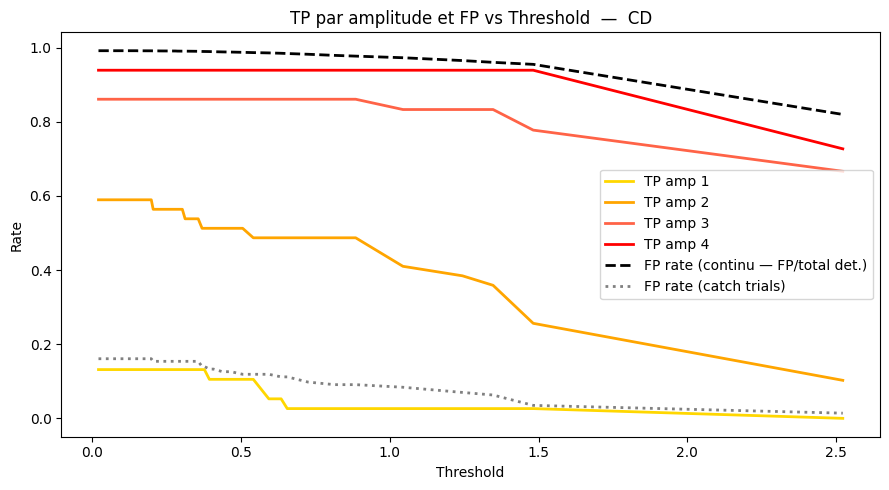

Number of false detection at the best threshold (0.02): 11264 (FP rate: 0.99)


In [43]:
# Creation CD1 : pic principal 0-50ms (amp4)

Pop_Vect_Stim  = STM_by_amp[4][:, 50:55].mean(axis=1)
Pop_Vect_Catch = CATCH_MTRX[:, 50:55].mean(axis=1)

CD = Pop_Vect_Stim - Pop_Vect_Catch
CD = CD / (np.linalg.norm(CD) + 1e-12)

print("CD1 norm:", np.linalg.norm(CD), "shape:", CD.shape)

# Detection sur signal continu via projection CD1

# projection
score = CD @ AP_Bin_Matrx
t_sig = np.arange(len(score)) * Bin_size

# Peak detection
tol_post     = 0.05   # fenetre 50ms apres stim pour compter un TP
refractory_s = 0.2    # periode refractaire entre deux detections

t_start = float(tr["start_time"].min())
t_end   = float(tr["stop_time"].max())

def detect_peaks(score, t, thr, refractory_s, Bin_size, t_start, t_end):
    mask = (t >= t_start) & (t <= t_end) & (score > thr)
    idx  = np.where(mask)[0]
    if idx.size == 0:
        return np.array([], dtype=float)
    cuts   = np.where(np.diff(idx) > 1)[0] + 1
    groups = np.split(idx, cuts)
    peaks  = np.array([g[np.argmax(score[g])] for g in groups], dtype=int)
    min_b  = int(np.round(refractory_s / Bin_size))
    keep   = [peaks[0]]
    for p in peaks[1:]:
        if p - keep[-1] >= min_b:
            keep.append(p)
        elif score[p] > score[keep[-1]]:
            keep[-1] = p
    return t[np.array(keep, dtype=int)]

# threshold
in_range = (t_sig >= t_start) & (t_sig <= t_end)
ths      = np.percentile(score[in_range], np.linspace(50, 99.9, 80))

all_stim_times = np.sort(np.concatenate([Stim_times_by_amp[a] for a in amps_stim]))
n_catch_trials = len(Catch_times)

tp_curves        = {a: [] for a in amps_stim}
fp_cont_curve    = []   # FP / total detections (signal continu)
fp_catch_curve   = []   # detections dans fenetres catch / n_catch_trials

for thr in ths:
    det_t = detect_peaks(score, t_sig, thr, refractory_s, Bin_size, t_start, t_end)
    n_det = max(len(det_t), 1)

    # FP continu : detections hors de toute fenetre stim / total detections
    in_win_any = np.zeros(len(det_t), dtype=bool)
    for st in all_stim_times:
        in_win_any |= (det_t >= st) & (det_t <= st + tol_post)
    fp_cont_curve.append(np.sum(~in_win_any) / n_det)

    # keep number of false detections at best threshold for later
    if len(fp_cont_curve) == 1:  # first threshold (lowest)
        in_win_any_at_best = in_win_any.copy()
        n_det_at_best = n_det

    # FP catch : combien de catch trials ont une detection dans leur fenetre
    hits_catch = sum(
        np.any((det_t >= st) & (det_t <= st + tol_post))
        for st in Catch_times
    )
    fp_catch_curve.append(hits_catch / max(n_catch_trials, 1))

    # TP par amplitude
    for a in amps_stim:
        hits = sum(
            np.any((det_t >= st) & (det_t <= st + tol_post))
            for st in Stim_times_by_amp[a]
        )
        tp_curves[a].append(hits / max(len(Stim_times_by_amp[a]), 1))

tp_curves      = {a: np.array(tp_curves[a]) for a in amps_stim}
fp_cont_curve  = np.array(fp_cont_curve)
fp_catch_curve = np.array(fp_catch_curve)

# plot
colors_amp = {1: "gold", 2: "orange", 3: "tomato", 4: "red"}

plt.figure(figsize=(9, 5))
for a in amps_stim:
    plt.plot(ths, tp_curves[a], color=colors_amp[a], lw=2, label=f"TP amp {a}")
plt.plot(ths, fp_cont_curve,  color="black",  lw=2, linestyle="--", label="FP rate (continu — FP/total det.)")
plt.plot(ths, fp_catch_curve, color="gray",   lw=2, linestyle=":",  label="FP rate (catch trials)")
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("TP par amplitude et FP vs Threshold  —  CD")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Number of false detection at the best threshold ({ths[0]:.2f}): {n_det_at_best} (FP rate: {np.sum(~in_win_any_at_best) / n_det_at_best:.2f})")


Meilleur threshold : 1.4821  |  TP4=0.94  FP=0.96
Détections totales : 1564


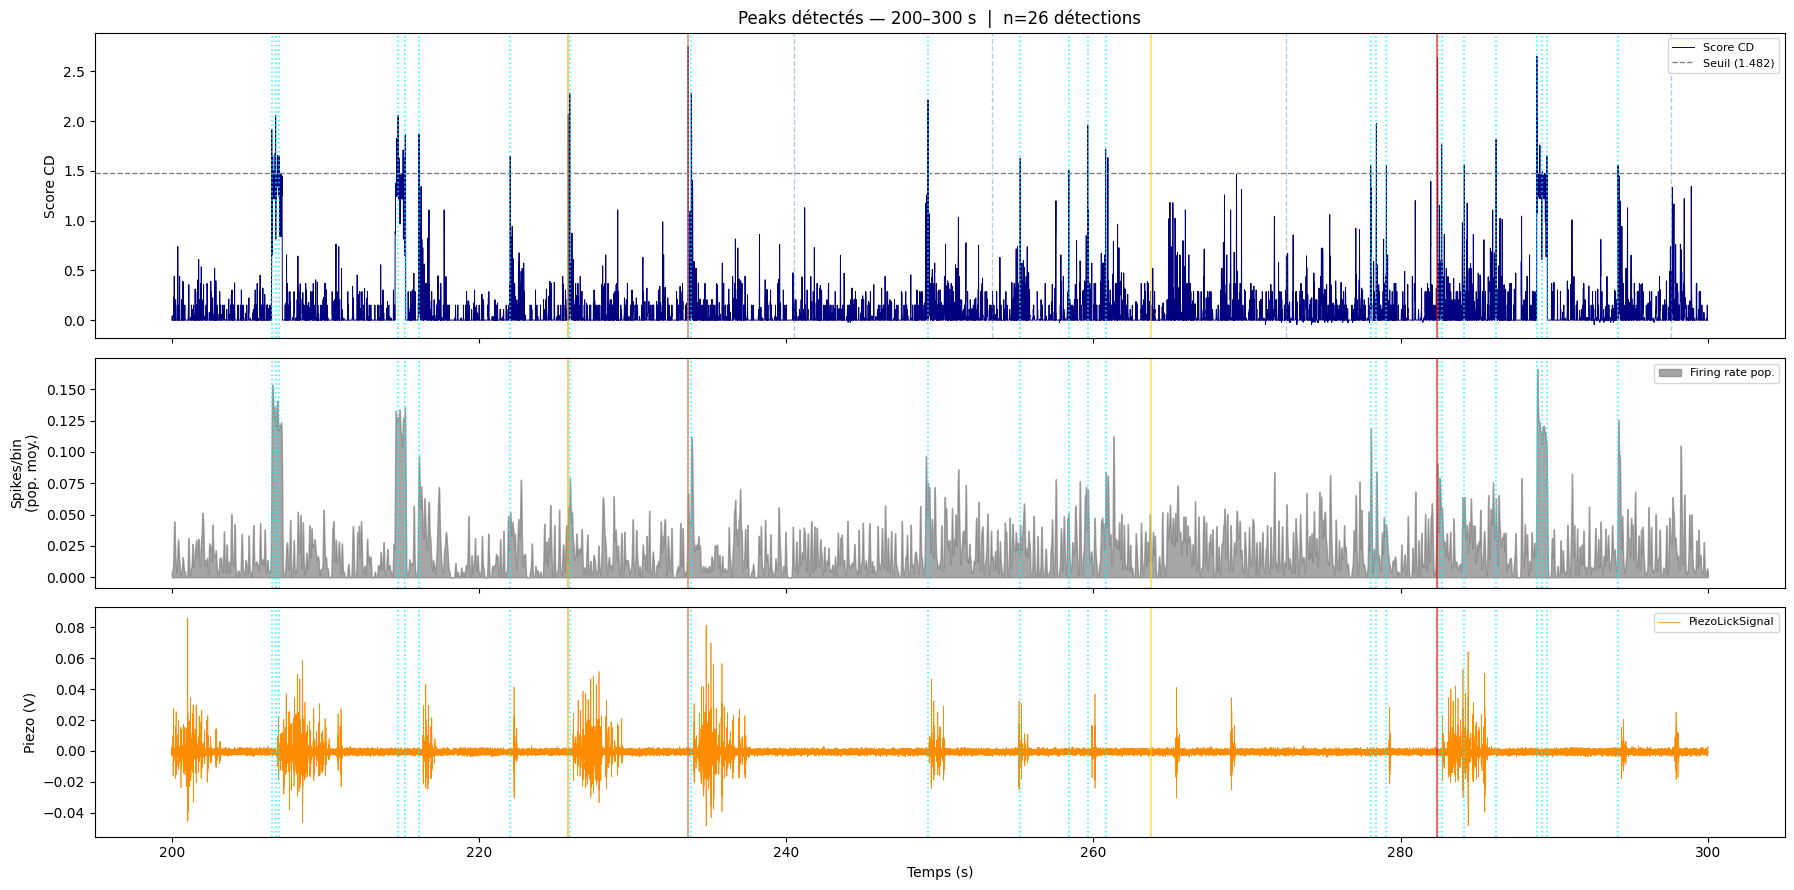

In [44]:
# Meilleur threshold + plot 200-300 s : peaks détectés / activité moy / piezo

from scipy.ndimage import gaussian_filter1d

# Meilleur threshold : max(TP4 - FP_continu)
best_i   = np.argmax(tp_curves[4] - fp_cont_curve)
best_thr = ths[best_i]
print(f"Meilleur threshold : {best_thr:.4f}  |  TP4={tp_curves[4][best_i]:.2f}  FP={fp_cont_curve[best_i]:.2f}")

det_t_best = detect_peaks(score, t_sig, best_thr, refractory_s, Bin_size, t_start, t_end)
print(f"Détections totales : {len(det_t_best)}")

# Fenêtre de visualisation
t0_vis, t1_vis = 200.0, 300.0

mask_score_v = (t_sig    >= t0_vis) & (t_sig    <= t1_vis)
mask_piezo_v = (piezo_ts >= t0_vis) & (piezo_ts <= t1_vis)
det_win      = det_t_best[(det_t_best >= t0_vis) & (det_t_best <= t1_vis)]

b0v, b1v  = int(t0_vis * AP_Bin_Resolution), int(t1_vis * AP_Bin_Resolution)
t_rate_v  = np.arange(b0v, b1v) * Bin_size
rate_sm_v = gaussian_filter1d(AP_Bin_Matrx[:, b0v:b1v].mean(axis=0), sigma=3)

colors_amp = {1: "gold", 2: "orange", 3: "tomato", 4: "red"}

fig, axes = plt.subplots(3, 1, figsize=(18, 9), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1.5, 1.5]})

# Score + peaks détectés
ax = axes[0]
ax.plot(t_sig[mask_score_v], score[mask_score_v], color="navy", lw=0.7, label="Score CD")
ax.axhline(best_thr, color="gray", lw=1.0, linestyle="--", label=f"Seuil ({best_thr:.3f})")
for dt in det_win:
    ax.axvline(dt, color="cyan", alpha=0.8, lw=1.2, linestyle=":")
for a in amps_stim:
    for st in Stim_times_by_amp[a]:
        if t0_vis <= st <= t1_vis:
            ax.axvline(st, color=colors_amp[a], alpha=0.7, lw=1.2)
for ct in Catch_times:
    if t0_vis <= ct <= t1_vis:
        ax.axvline(ct, color="steelblue", alpha=0.4, lw=1.0, linestyle="--")
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(),
          fontsize=8, loc="upper right")
ax.set_ylabel("Score CD")
ax.set_title(f"Peaks détectés — {t0_vis:.0f}–{t1_vis:.0f} s  |  n={len(det_win)} détections")

# Activité moyenne
ax2 = axes[1]
ax2.fill_between(t_rate_v, rate_sm_v, alpha=0.7, color="gray", label="Firing rate pop.")
for dt in det_win:
    ax2.axvline(dt, color="cyan", alpha=0.8, lw=1.2, linestyle=":")
for a in amps_stim:
    for st in Stim_times_by_amp[a]:
        if t0_vis <= st <= t1_vis:
            ax2.axvline(st, color=colors_amp[a], alpha=0.7, lw=1.2)
ax2.set_ylabel("Spikes/bin\n(pop. moy.)")
ax2.legend(fontsize=8, loc="upper right")

# Piezo
ax3 = axes[2]
ax3.plot(piezo_ts[mask_piezo_v], piezo_data[mask_piezo_v],
         color="darkorange", lw=0.5, label="PiezoLickSignal")
for dt in det_win:
    ax3.axvline(dt, color="cyan", alpha=0.8, lw=1.2, linestyle=":")
for a in amps_stim:
    for st in Stim_times_by_amp[a]:
        if t0_vis <= st <= t1_vis:
            ax3.axvline(st, color=colors_amp[a], alpha=0.7, lw=1.2)
ax3.set_ylabel("Piezo (V)")
ax3.set_xlabel("Temps (s)")
ax3.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()
